In [ ]:
# Instalación de dependencias
!pip -q install --upgrade torch torchaudio --index-url https://download.pytorch.org/whl/cu121

# Importación de independencias
import torch
import torchaudio

# Si imprime algo, está bien
print(torch.__version__, torchaudio.__version__)

In [ ]:
# Instalación de API de Wand
!pip -q install wand weave

In [20]:
import wandb
!wandb login

wandb: Currently logged in as: nicofacultad001 (nicofacultad001-di-tella-emprende) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [ ]:
!pip -q install soundfile

In [23]:
import random
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchaudio
from torchaudio import transforms as T

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import shutil, os

from torch.cuda.amp import autocast, GradScaler  # Para mixed precision (FP16)

import json
import os
from datetime import datetime

# Carpetas
METADATA_DIR = Path("metadata")
MODELS_DIR = Path("models")
METADATA_DIR.mkdir(exist_ok=True)
MODELS_DIR.mkdir(exist_ok=True)

# Contador global para nombres únicos
EXPERIMENT_COUNTER = 0

# ===== Parámetros mínimos =====
SEED = 42
# === RUTA CORRECTA: PADRE DE SpeechCommands ===
DATA_ROOT = Path(r"C:\Users\elbou\Documents\Di Tella Programacion\TD6\tp3\content\data\speech_commands")

# Verifica que existe
if not DATA_ROOT.exists():
    raise FileNotFoundError(f"No existe: {DATA_ROOT}")
print(f"Dataset local: {DATA_ROOT.resolve()}")


DATA_ROOT.mkdir(parents=True, exist_ok=True)

CLASSES = ['yes','no','up','down','left','right','on','off','stop','go']
NATIVE_SR = 16000
N_FFT = 256
HOP_LENGTH = 160
N_MELS = 32

BATCH_SIZE = 128
EPOCHS = 50
LR = 1e-3

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
if DEVICE == 'cuda': torch.cuda.manual_seed_all(SEED)

print("Device:", DEVICE)
print("Datos en:", DATA_ROOT.resolve())

############################   BORRAR LUEGO   ####################################### 
import torchaudio
print("Backends disponibles:", torchaudio.list_audio_backends())

# Prueba con un archivo real
path12 = r"C:\Users\elbou\Documents\Di Tella Programacion\TD6\tp3\content\data\speech_commands\SpeechCommands\speech_commands_v0.02\yes\00f0204f_nohash_0.wav"
waveform, sr = torchaudio.load(path12)
print(f"Audio cargado: {waveform.shape}, sr={sr}")


Dataset local: C:\Users\elbou\Documents\Di Tella Programacion\TD6\tp3\content\data\speech_commands
Device: cuda
Datos en: C:\Users\elbou\Documents\Di Tella Programacion\TD6\tp3\content\data\speech_commands
Backends disponibles: ['soundfile']
Audio cargado: torch.Size([1, 16000]), sr=16000


In [ ]:
def save_experiment(
    model, 
    config: dict, 
    train_metrics: dict, 
    val_metrics: dict, 
    experiment_name: str = None,
    save_model: bool = True
):
    """
    Guarda:
    - 1 JSON con hiperparámetros + resultados
    - 1 .pth con el mejor modelo (si save_model=True)
    """
    global EXPERIMENT_COUNTER
    EXPERIMENT_COUNTER += 1

    # Nombre único
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    base_name = f"exp{EXPERIMENT_COUNTER:02d}_{experiment_name or 'unnamed'}"
    
    # === RESULTADOS FINALES ===
    results = {
        "train_loss": train_metrics["loss"],
        "train_acc": train_metrics["acc"],
        "val_loss": val_metrics["loss"],
        "val_acc": val_metrics["acc"],
        "best_val_acc": val_metrics.get("best_acc", val_metrics["acc"]),
        "timestamp": timestamp
    }

    # === METADATA COMPLETA ===
    metadata = {
        "experiment_id": f"exp{EXPERIMENT_COUNTER:02d}",
        "name": base_name,
        "config": config,
        "results": results
    }

    # === GUARDAR JSON ===
    json_path = METADATA_DIR / f"{base_name}.json"
    with open(json_path, 'w', encoding='utf-8') as f:
        json.dump(metadata, f, indent=2, ensure_ascii=False)
    print(f"JSON guardado: {json_path}")

    # === GUARDAR MODELO (solo el mejor) ===
    if save_model and model is not None:
        model_path = MODELS_DIR / f"{base_name}.pth"
        torch.save(model.state_dict(), model_path)
        print(f"Modelo guardado: {model_path}")

    return json_path, model_path if save_model else None

In [ ]:
def _lists_exist(root: Path) -> bool:
    base = root / "SpeechCommands" / "speech_commands_v0.02"
    print("EXISTEN!!!!")
    return (base / "validation_list.txt").exists() and (base / "testing_list.txt").exists()

def _bootstrap_download(root: Path):
    """Descarga completa (con subset=None) para garantizar que existan las listas oficiales."""
    # limpiar descargas incompletas
    shutil.rmtree(root / "SpeechCommands", ignore_errors=True)
    _ = torchaudio.datasets.SPEECHCOMMANDS(root=str(root), download=True, subset=None)
    if not _lists_exist(root):
        raise RuntimeError("No se pudieron crear las listas oficiales tras la descarga.")

class MiniSpeechCommandsRaw(Dataset):
    """
    - Intenta usar/download el split pedido.
    - Si detecta dataset incompleto, se auto-repara (bootstrap con subset=None) y reintenta.
    - Devuelve (waveform_crudo, sr, label_id) sin preprocesar.
    """
    def __init__(self, root, classes, subset='training'):
        root = Path(root)
        root.mkdir(parents=True, exist_ok=True)

        try:
            # Intento normal: si ya está en /content, no vuelve a bajar
            base = torchaudio.datasets.SPEECHCOMMANDS(
                root=str(root), download=True, subset=subset
            )
            # Algunas veces torchaudio no tira excepción, pero las listas faltan:
            if not _lists_exist(root):
                raise FileNotFoundError("List files missing after download.")
        except FileNotFoundError:
            # Auto-reparación: descarga completa y reintento sin download
            _bootstrap_download(root)
            base = torchaudio.datasets.SPEECHCOMMANDS(
                root=str(root), download=False, subset=subset
            )

        self.classes = list(classes)
        c2i = {c: i for i, c in enumerate(self.classes)}
        self.items = []
        for i in tqdm(range(len(base)), desc=f"Cargando/filtrando '{subset}'", unit="audio"):
            wav, sr, label, *_ = base[i]
            if label in c2i:
                self.items.append((wav, sr, c2i[label]))

        if not self.items:
            raise RuntimeError(f"Sin ejemplos para {self.classes} en subset={subset}.")

    def __len__(self): return len(self.items)
    def __getitem__(self, idx): return self.items[idx]



In [ ]:
print("------ Entro a TRAIN ------")
train_ds = MiniSpeechCommandsRaw(DATA_ROOT, CLASSES, subset='training')

In [ ]:
print("------ Entro a VAL ------")
val_ds   = MiniSpeechCommandsRaw(DATA_ROOT, CLASSES, subset='validation')

In [ ]:
print("------ Entro a TEST ------")
test_ds  = MiniSpeechCommandsRaw(DATA_ROOT, CLASSES, subset='testing')

print(f"Tamaños -> train: {len(train_ds)} | val: {len(val_ds)} | test: {len(test_ds)}")

Clase: down | sr: 16000 | shape: (1, 16000) | dur: 1.00s


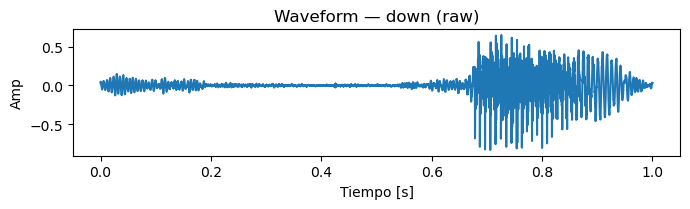

Clase: stop | sr: 16000 | shape: (1, 16000) | dur: 1.00s


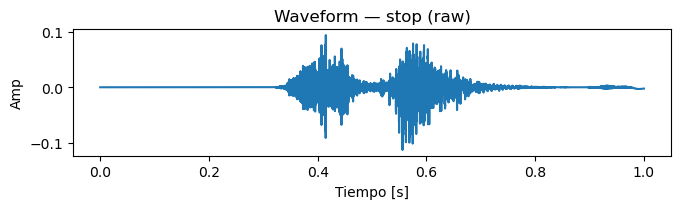

In [15]:
def plot_waveform(wav, sr, title="Waveform (raw)"):
    x = wav.squeeze().cpu().numpy()
    t = np.arange(len(x))/sr
    plt.figure(figsize=(7, 2.2))
    plt.plot(t, x)
    plt.xlabel("Tiempo [s]"); plt.ylabel("Amp"); plt.title(title)
    plt.tight_layout(); plt.show()

for _ in range(2):
    idx = random.randrange(len(train_ds))
    wav, sr, y = train_ds[idx]
    print(f"Clase: {CLASSES[y]} | sr: {sr} | shape: {tuple(wav.shape)} | dur: {wav.shape[-1]/sr:.2f}s")
    plot_waveform(wav, sr, title=f"Waveform — {CLASSES[y]} (raw)")


Ejemplo idx=15795 | clase=on | sr=16000 | dur=1.00s


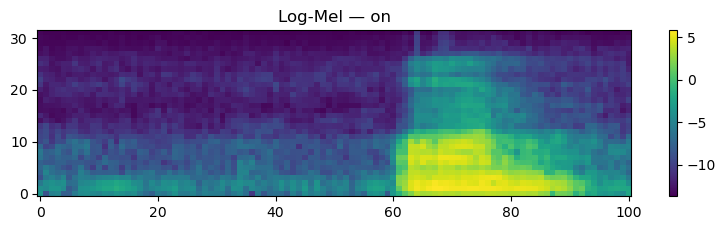

▶️ Reproducir:


In [16]:
from IPython.display import Audio, display

mel_tf_vis = T.MelSpectrogram(
    sample_rate=NATIVE_SR,
    n_fft=N_FFT,
    hop_length=HOP_LENGTH,
    n_mels=N_MELS
).to(DEVICE)  # ← Mueve a GPU para acelerar


#blogpost sobre MEL (https://medium.com/analytics-vidhya/understanding-the-mel-spectrogram-fca2afa2ce53)

def plot_logmel(wav, sr, title="Log-Mel"):
    # MOVER wav a GPU para usar mel_tf_vis (que está en GPU)
    wav_gpu = wav.to(DEVICE) if wav.device != DEVICE else wav
    
    with torch.no_grad():
        M = mel_tf_vis(wav_gpu)  # (1, F, Tm) o (F, Tm)
        LM = torch.log(M + 1e-6)
        if LM.ndim == 3 and LM.shape[0] == 1:
            LM = LM.squeeze(0)
        elif LM.ndim == 1:
            LM = LM.unsqueeze(0)
        LM = LM.cpu().numpy()  # Volver a CPU para matplotlib

    plt.figure(figsize=(8, 2.4))
    plt.imshow(LM, aspect='auto', origin='lower')
    plt.title(title); plt.colorbar(); plt.tight_layout(); plt.show()

def play_audio(wav, sr):
    x = wav.squeeze().cpu().numpy()
    display(Audio(x, rate=sr))

idx = np.random.randint(len(train_ds))
wav, sr, y = train_ds[idx]
print(f"Ejemplo idx={idx} | clase={CLASSES[y]} | sr={sr} | dur={wav.shape[-1]/sr:.2f}s")
plot_logmel(wav, sr, title=f"Log-Mel — {CLASSES[y]}")
print("▶️ Reproducir:")
play_audio(wav, sr)


In [17]:
def collate_wave_flat(batch):
    """
    batch: lista de (wav_crudo, sr, y) con longitudes variables.
    1) pad por batch a la longitud máxima del batch
    2) aplanar a (B, Tmax) para MLP
    """
    max_len = max(wav.shape[-1] for wav, _, _ in batch)
    padded, ys = [], []
    for wav, sr, y in batch:
        pad_len = max_len - wav.shape[-1]
        if pad_len > 0:
            wav = F.pad(wav, (0, pad_len))   # (1, Tmax)
        padded.append(wav)
        ys.append(y)
    W = torch.stack(padded, dim=0)          # (B, 1, Tmax)
    X = W.flatten(1)                        # (B, Tmax)  <- waveform crudo aplanado
    y = torch.tensor(ys, dtype=torch.long)
    return X, y

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, collate_fn=collate_wave_flat)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, collate_fn=collate_wave_flat)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, collate_fn=collate_wave_flat)

# Dimensión de entrada para el MLP
xb, yb = next(iter(train_loader))
in_features = xb.shape[1]
num_classes = len(CLASSES)
print("in_features:", in_features, "| num_classes:", num_classes)

in_features: 16000 | num_classes: 10


In [18]:
class MLP(nn.Module):
    def __init__(self, in_features, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )
    def forward(self, x):
        return self.net(x)

model = MLP(in_features, num_classes).to(DEVICE)
opt = torch.optim.SGD(model.parameters(), lr=LR)
crit = nn.CrossEntropyLoss()

In [24]:
wandb.init(
    project="ej1_mlp_mel_baseline",
    name="1L_128_ReLU",
    reinit=True,
    config={
        "learning_rate": LR,
        "epochs": EPOCHS,
        "batch_size": BATCH_SIZE,
        "n_fft": N_FFT,
        "hop_length": HOP_LENGTH,
        "n_mels": N_MELS,
        "architecture": "MLP"
    }
)

best_val_acc = 0.0
best_model_state = None
final_train_metrics = {"loss": 0.0, "acc": 0.0}
final_val_metrics = {"loss": 0.0, "acc": 0.0}

for epoch in range(1, EPOCHS+1):
    model.train()
    total, correct, loss_sum = 0, 0, 0.0
    for X, y in train_loader:
        X, y = X.to(DEVICE), y.to(DEVICE)
        opt.zero_grad()
        logits = model(X)
        loss = crit(logits, y)
        loss.backward()
        opt.step()

        loss_sum += loss.item() * y.size(0)
        pred = logits.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.size(0)

    train_loss = loss_sum / total
    train_acc = correct / total

    # Validation
    model.eval()
    total_val, correct_val, loss_sum_val = 0, 0, 0.0
    with torch.no_grad():
        for X_val, y_val in val_loader:
            X_val, y_val = X_val.to(DEVICE), y_val.to(DEVICE)
            logits_val = model(X_val)
            loss_val = crit(logits_val, y_val)
            loss_sum_val += loss_val.item() * y_val.size(0)
            pred_val = logits_val.argmax(dim=1)
            correct_val += (pred_val == y_val).sum().item()
            total_val += y_val.size(0)

    val_loss = loss_sum_val / total_val
    val_acc = correct_val / total_val

    final_train_metrics = {"loss": train_loss, "acc": train_acc}
    final_val_metrics = {"loss": val_loss, "acc": val_acc}

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = model.state_dict().copy()
    final_val_metrics["best_acc"] = best_val_acc

    print(f"Epoch {epoch:02d} | train_loss={train_loss:.3f} | train_acc={train_acc:.3f} | val_loss={val_loss:.3f} | val_acc={val_acc:.3f}")
    wandb.log({"epoch": epoch, "train_loss": train_loss, "train_acc": train_acc, "val_loss": val_loss, "val_acc": val_acc})

wandb.finish()

# --- CARGAR MEJOR MODELO ---
if best_model_state is not None:
    model.load_state_dict(best_model_state)

# --- GUARDAR JSON + .pth ---
config = {
    "exercise": 1,
    "learning_rate": LR,
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "architecture": "MLP",
    "hidden_sizes": [128],
    "activation": "ReLU"
}

save_experiment(
    model=model,  # ← modelo con mejor estado
    config=config,
    train_metrics=final_train_metrics,
    val_metrics=final_val_metrics,
    experiment_name="Ej1_MLP_Baseline",
    save_model=True
)

Epoch 01 | train_loss=2.286 | train_acc=0.188 | val_loss=2.301 | val_acc=0.115
Epoch 02 | train_loss=2.286 | train_acc=0.189 | val_loss=2.301 | val_acc=0.115
Epoch 03 | train_loss=2.286 | train_acc=0.190 | val_loss=2.301 | val_acc=0.114
Epoch 04 | train_loss=2.286 | train_acc=0.191 | val_loss=2.301 | val_acc=0.114
Epoch 05 | train_loss=2.285 | train_acc=0.192 | val_loss=2.301 | val_acc=0.115
Epoch 06 | train_loss=2.285 | train_acc=0.192 | val_loss=2.301 | val_acc=0.115
Epoch 07 | train_loss=2.285 | train_acc=0.194 | val_loss=2.301 | val_acc=0.115
Epoch 08 | train_loss=2.285 | train_acc=0.195 | val_loss=2.301 | val_acc=0.114
Epoch 09 | train_loss=2.285 | train_acc=0.195 | val_loss=2.301 | val_acc=0.115
Epoch 10 | train_loss=2.284 | train_acc=0.196 | val_loss=2.301 | val_acc=0.115
Epoch 11 | train_loss=2.284 | train_acc=0.197 | val_loss=2.301 | val_acc=0.115
Epoch 12 | train_loss=2.284 | train_acc=0.197 | val_loss=2.301 | val_acc=0.115
Epoch 13 | train_loss=2.284 | train_acc=0.199 | val_

epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇███
train_acc,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇████
train_loss,████▇▇▇▇▇▇▆▆▆▆▆▆▅▅▅▅▅▅▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▁▁▁
val_acc,▂▂▂▃▄▂▃▄▃▃▄▃▂▁▂▃▅▅▅▅▅▆▆▅▅▆▇▇▇▅▆▆▆▇▇██▇▇▇
val_loss,████▇▇▇▇▇▇▆▆▆▆▆▆▅▅▅▅▅▅▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▁▁▁
epoch,50
train_acc,0.23231
train_loss,2.27631
val_acc,0.11747
val_loss,2.30019


JSON guardado: metadata\exp01_Ej1_MLP_Baseline.json
Modelo guardado: models\exp01_Ej1_MLP_Baseline.pth


(WindowsPath('metadata/exp01_Ej1_MLP_Baseline.json'),
 WindowsPath('models/exp01_Ej1_MLP_Baseline.pth'))

In [25]:
model.eval()
with torch.no_grad():
    X, y = next(iter(val_loader))
    pred = model(X.to(DEVICE)).argmax(1).cpu().numpy()
    print("Predicciones (primeros 20):", [CLASSES[i] for i in pred[:20]])


Predicciones (primeros 20): ['yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'down', 'yes', 'stop', 'yes', 'yes', 'off', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'down', 'yes']


In [26]:
##############################################################################
################################ EJERICICO 2 #################################
##############################################################################

# Celda: Definir Modelo Flexible para Variar Arquitectura
class FlexibleMLP(nn.Module):
    def __init__(self, input_size, hidden_sizes, output_size, activation=nn.ReLU()):
        super().__init__()
        layers = []
        prev_size = input_size
        for hs in hidden_sizes:
            layers.append(nn.Linear(prev_size, hs))
            layers.append(activation)
            prev_size = hs
        layers.append(nn.Linear(prev_size, output_size))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [ ]:
# Input size fijo basado en Mel Spectrogram
input_size = NATIVE_SR

# Experimentos para Ejercicio 2
experiments = [
    {"name": "1L_64", "hidden_sizes": [64]},
    {"name": "1L_256", "hidden_sizes": [256]},
    {"name": "2L_128_64", "hidden_sizes": [128, 64]},
    {"name": "2L_256_128", "hidden_sizes": [256, 128]},
    {"name": "3L_512_256_128", "hidden_sizes": [512, 256, 128]},
]

# Bucle para correr cada experimento
for exp in experiments:
    print(f"\nINICIANDO EXPERIMENTO: {exp['name']}")

    # Modelo
    model = FlexibleMLP(input_size, exp["hidden_sizes"], len(CLASSES)).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    crit = nn.CrossEntropyLoss()

    # WandB
    wandb.init(
        project="ej2_arquitectura_mlp",
        name=exp["name"],
        reinit=True,
        config={
            "learning_rate": LR,
            "epochs": EPOCHS,
            "batch_size": BATCH_SIZE,
            "n_fft": N_FFT,
            "hop_length": HOP_LENGTH,
            "n_mels": N_MELS,
            "architecture": "MLP",
            "hidden_sizes": exp["hidden_sizes"]
        }
    )

    # --- GUARDAR CONFIG ANTES DE FINISH ---
    config_dict = dict(wandb.config)
    config_dict["exercise"] = 2

    # Trackers por experimento
    best_val_acc = 0.0
    best_model_state = None
    final_train_metrics = {"loss": 0.0, "acc": 0.0}
    final_val_metrics = {"loss": 0.0, "acc": 0.0}

    # Entrenamiento
    for epoch in range(1, EPOCHS + 1):
        model.train()
        total, correct, loss_sum = 0, 0, 0.0
        for X, y in train_loader:
            X, y = X.to(DEVICE), y.to(DEVICE)
            opt.zero_grad()
            logits = model(X)
            loss = crit(logits, y)
            loss.backward()
            opt.step()

            loss_sum += loss.item() * y.size(0)
            correct += (logits.argmax(dim=1) == y).sum().item()
            total += y.size(0)

        train_loss = loss_sum / total
        train_acc = correct / total

        # Validación
        model.eval()
        total_val, correct_val, loss_sum_val = 0, 0, 0.0
        with torch.no_grad():
            for X_val, y_val in val_loader:
                X_val, y_val = X_val.to(DEVICE), y_val.to(DEVICE)
                logits_val = model(X_val)
                loss_val = crit(logits_val, y_val)
                loss_sum_val += loss_val.item() * y_val.size(0)
                correct_val += (logits_val.argmax(dim=1) == y_val).sum().item()
                total_val += y_val.size(0)

        val_loss = loss_sum_val / total_val
        val_acc = correct_val / total_val

        # Trackear mejor
        final_train_metrics = {"loss": train_loss, "acc": train_acc}
        final_val_metrics = {"loss": val_loss, "acc": val_acc}

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = model.state_dict().copy()
        final_val_metrics["best_acc"] = best_val_acc

        print(f"Exp {exp['name']} | Epoch {epoch:02d} | train_loss={train_loss:.3f} | val_acc={val_acc:.3f}")
        wandb.log({"epoch": epoch, "train_loss": train_loss, "train_acc": train_acc, "val_loss": val_loss, "val_acc": val_acc})

    # --- TERMINAR W&B ANTES DE GUARDAR ---
    wandb.finish()

    # --- CARGAR MEJOR MODELO ---
    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    # --- GUARDAR JSON + .pth ---
    save_experiment(
        model=model,
        config=config_dict,  # ← ya guardada antes
        train_metrics=final_train_metrics,
        val_metrics=final_val_metrics,
        experiment_name=f"Ej2_{exp['name']}",
        save_model=True
    )

    print(f"EXPERIMENTO {exp['name']} COMPLETADO Y GUARDADO\n")


INICIANDO EXPERIMENTO: 1L_64


Exp 1L_64 | Epoch 01 | train_loss=2.296 | val_acc=0.127
Exp 1L_64 | Epoch 02 | train_loss=2.094 | val_acc=0.141
Exp 1L_64 | Epoch 03 | train_loss=1.816 | val_acc=0.143
Exp 1L_64 | Epoch 04 | train_loss=1.550 | val_acc=0.142
Exp 1L_64 | Epoch 05 | train_loss=1.320 | val_acc=0.148
Exp 1L_64 | Epoch 06 | train_loss=1.130 | val_acc=0.149
Exp 1L_64 | Epoch 07 | train_loss=0.976 | val_acc=0.149
Exp 1L_64 | Epoch 08 | train_loss=0.848 | val_acc=0.151
Exp 1L_64 | Epoch 09 | train_loss=0.748 | val_acc=0.152
Exp 1L_64 | Epoch 10 | train_loss=0.651 | val_acc=0.151
Exp 1L_64 | Epoch 11 | train_loss=0.579 | val_acc=0.153
Exp 1L_64 | Epoch 12 | train_loss=0.528 | val_acc=0.152
Exp 1L_64 | Epoch 13 | train_loss=0.464 | val_acc=0.154
Exp 1L_64 | Epoch 14 | train_loss=0.412 | val_acc=0.149
Exp 1L_64 | Epoch 15 | train_loss=0.397 | val_acc=0.147
Exp 1L_64 | Epoch 16 | train_loss=0.368 | val_acc=0.148
Exp 1L_64 | Epoch 17 | train_loss=0.350 | val_acc=0.149
Exp 1L_64 | Epoch 18 | train_loss=0.321 | val_ac

epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
train_acc,▁▂▃▄▅▆▆▇▇▇▇▇▇▇▇█████████████████████████
train_loss,█▇▇▆▅▄▃▃▃▃▂▂▂▂▂▂▂▂▁▂▁▁▁▁▁▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▅▅▇▇██▇██▇▆▇▇▆▅▆▅▇▅▇▇▇▆▇▆▇▇▆▅▄▅▅▄▅▅▆▆▆▇
val_loss,▁▁▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▄▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇█████
epoch,50
train_acc,0.99623
train_loss,0.04852
val_acc,0.14853
val_loss,12.06857


JSON guardado: metadata\exp02_Ej2_1L_64.json
Modelo guardado: models\exp02_Ej2_1L_64.pth
EXPERIMENTO 1L_64 COMPLETADO Y GUARDADO


INICIANDO EXPERIMENTO: 1L_256


Exp 1L_256 | Epoch 01 | train_loss=2.294 | val_acc=0.132
Exp 1L_256 | Epoch 02 | train_loss=2.019 | val_acc=0.147
Exp 1L_256 | Epoch 03 | train_loss=1.606 | val_acc=0.159
Exp 1L_256 | Epoch 04 | train_loss=1.215 | val_acc=0.164
Exp 1L_256 | Epoch 05 | train_loss=0.911 | val_acc=0.160
Exp 1L_256 | Epoch 06 | train_loss=0.696 | val_acc=0.169
Exp 1L_256 | Epoch 07 | train_loss=0.561 | val_acc=0.161
Exp 1L_256 | Epoch 08 | train_loss=0.457 | val_acc=0.164
Exp 1L_256 | Epoch 09 | train_loss=0.434 | val_acc=0.156
Exp 1L_256 | Epoch 10 | train_loss=0.386 | val_acc=0.160
Exp 1L_256 | Epoch 11 | train_loss=0.310 | val_acc=0.157
Exp 1L_256 | Epoch 12 | train_loss=0.241 | val_acc=0.161
Exp 1L_256 | Epoch 13 | train_loss=0.201 | val_acc=0.158
Exp 1L_256 | Epoch 14 | train_loss=0.217 | val_acc=0.163
Exp 1L_256 | Epoch 15 | train_loss=0.234 | val_acc=0.159
Exp 1L_256 | Epoch 16 | train_loss=0.271 | val_acc=0.155
Exp 1L_256 | Epoch 17 | train_loss=0.268 | val_acc=0.157
Exp 1L_256 | Epoch 18 | train_l

...

JSON guardado: metadata\exp03_Ej2_1L_256.json
Modelo guardado: models\exp03_Ej2_1L_256.pth
EXPERIMENTO 1L_256 COMPLETADO Y GUARDADO


INICIANDO EXPERIMENTO: 2L_128_64


Exp 2L_128_64 | Epoch 01 | train_loss=2.291 | val_acc=0.129
Exp 2L_128_64 | Epoch 02 | train_loss=2.100 | val_acc=0.145
Exp 2L_128_64 | Epoch 03 | train_loss=1.709 | val_acc=0.151
Exp 2L_128_64 | Epoch 04 | train_loss=1.323 | val_acc=0.150
Exp 2L_128_64 | Epoch 05 | train_loss=0.991 | val_acc=0.153
Exp 2L_128_64 | Epoch 06 | train_loss=0.759 | val_acc=0.151
Exp 2L_128_64 | Epoch 07 | train_loss=0.644 | val_acc=0.159
Exp 2L_128_64 | Epoch 08 | train_loss=0.489 | val_acc=0.154
Exp 2L_128_64 | Epoch 09 | train_loss=0.405 | val_acc=0.158
Exp 2L_128_64 | Epoch 10 | train_loss=0.340 | val_acc=0.153
Exp 2L_128_64 | Epoch 11 | train_loss=0.306 | val_acc=0.156
Exp 2L_128_64 | Epoch 12 | train_loss=0.298 | val_acc=0.149
Exp 2L_128_64 | Epoch 13 | train_loss=0.270 | val_acc=0.157
Exp 2L_128_64 | Epoch 14 | train_loss=0.220 | val_acc=0.150
Exp 2L_128_64 | Epoch 15 | train_loss=0.184 | val_acc=0.151
Exp 2L_128_64 | Epoch 16 | train_loss=0.150 | val_acc=0.151
Exp 2L_128_64 | Epoch 17 | train_loss=0.

epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
train_acc,▁▂▄▅▆▇▇▇▇▇██████████████████████████████
train_loss,█▇▆▅▄▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▅▆▆▇█▇█▇▇▇▆▆▆▆▇▇▇▅▆▆▇▆▇▆▇▇▇▅▆▆▅▇▆▅▆▇▅▅▇
val_loss,▁▁▁▁▂▂▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇███▇
epoch,50
train_acc,0.96737
train_loss,0.14179
val_acc,0.1542
val_loss,15.33512


JSON guardado: metadata\exp04_Ej2_2L_128_64.json
Modelo guardado: models\exp04_Ej2_2L_128_64.pth
EXPERIMENTO 2L_128_64 COMPLETADO Y GUARDADO


INICIANDO EXPERIMENTO: 2L_256_128


Exp 2L_256_128 | Epoch 01 | train_loss=2.286 | val_acc=0.132
Exp 2L_256_128 | Epoch 02 | train_loss=2.053 | val_acc=0.150
Exp 2L_256_128 | Epoch 03 | train_loss=1.594 | val_acc=0.166
Exp 2L_256_128 | Epoch 04 | train_loss=1.126 | val_acc=0.162
Exp 2L_256_128 | Epoch 05 | train_loss=0.769 | val_acc=0.168
Exp 2L_256_128 | Epoch 06 | train_loss=0.531 | val_acc=0.166
Exp 2L_256_128 | Epoch 07 | train_loss=0.423 | val_acc=0.174
Exp 2L_256_128 | Epoch 08 | train_loss=0.354 | val_acc=0.159
Exp 2L_256_128 | Epoch 09 | train_loss=0.255 | val_acc=0.161
Exp 2L_256_128 | Epoch 10 | train_loss=0.195 | val_acc=0.163
Exp 2L_256_128 | Epoch 11 | train_loss=0.163 | val_acc=0.161
Exp 2L_256_128 | Epoch 12 | train_loss=0.146 | val_acc=0.163
Exp 2L_256_128 | Epoch 13 | train_loss=0.165 | val_acc=0.164
Exp 2L_256_128 | Epoch 14 | train_loss=0.113 | val_acc=0.162
Exp 2L_256_128 | Epoch 15 | train_loss=0.086 | val_acc=0.165
Exp 2L_256_128 | Epoch 16 | train_loss=0.080 | val_acc=0.169
Exp 2L_256_128 | Epoch 1

In [ ]:
##############################################################################
################################ EJERICICO 3 #################################
##############################################################################
# ====== EJERCICIO 3: MEL vs WAV en MLP y CNN ======
# Requiere:
# - train_ds, val_ds, test_ds
# - CLASSES, DEVICE, BATCH_SIZE, EPOCHS, LR
# - FlexibleMLP ya definida (o la volvés a definir arriba)
# - torchaudio.transforms as T importado
# - wandb instalado y logueado

# Progreso y formato de tiempo (sin timers de bloque)
from tqdm.auto import tqdm
import math, time

def format_seconds(s):
    if s is None or math.isnan(s) or s == float("inf"):
        return "--:--"
    s = int(s)
    h, r = divmod(s, 3600)
    m, s = divmod(r, 60)
    return f"{h:d}:{m:02d}:{s:02d}" if h > 0 else f"{m:02d}:{s:02d}"


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchaudio
from torchaudio import transforms as T
import wandb

# ---------- Transforms MEL (CPU) ----------
mel_tf_cpu = T.MelSpectrogram(
    sample_rate=NATIVE_SR,
    n_fft=N_FFT,
    hop_length=HOP_LENGTH,
    n_mels=N_MELS,
    center=True,
    f_min=0.0,
    f_max=NATIVE_SR // 2,
    power=2.0,
)
amp_to_db = T.AmplitudeToDB(stype="power")

@torch.no_grad()
def wav_to_logmel_batch_cpu(W):  # W: (B, 1, T)
    M = mel_tf_cpu(W)            # (B, n_mels, Tm)
    LM = amp_to_db(M)            # (B, n_mels, Tm) en dB
    return LM


In [ ]:
# ---------- Collates ----------
def collate_mel_mlp(batch):
    """
    Devuelve X plano desde Log-Mel para MLP: (B, n_mels*Tm)
    """
    max_len = max(wav.shape[-1] for wav, _, _ in batch)
    padded, ys = [], []
    for wav, sr, y in batch:
        pad_len = max_len - wav.shape[-1]
        if pad_len > 0:
            wav = F.pad(wav, (0, pad_len))   # (1, Tmax)
        padded.append(wav)
        ys.append(y)
    W = torch.stack(padded, dim=0)           # (B, 1, Tmax)
    LM = wav_to_logmel_batch_cpu(W)          # (B, n_mels, Tm)
    X = LM.flatten(1)                        # (B, n_mels*Tm)
    y = torch.tensor(ys, dtype=torch.long)
    return X, y

def collate_mel_cnn(batch):
    """
    Devuelve tensor 4D para CNN: (B, 1, n_mels, Tm)
    """
    max_len = max(wav.shape[-1] for wav, _, _ in batch)
    padded, ys = [], []
    for wav, sr, y in batch:
        pad_len = max_len - wav.shape[-1]
        if pad_len > 0:
            wav = F.pad(wav, (0, pad_len))   # (1, Tmax)
        padded.append(wav)
        ys.append(y)

    W = torch.stack(padded, dim=0)           # (B, 1, Tmax)
    LM = wav_to_logmel_batch_cpu(W)          # puede ser (B, n_mels, Tm) O (B, 1, n_mels, Tm)

    # Normalizamos a (B, 1, n_mels, Tm)
    if LM.dim() == 3:
        # (B, n_mels, Tm) -> agrego canal
        X = LM.unsqueeze(1)
    elif LM.dim() == 4:
        # (B, C, n_mels, Tm) -> si C==1 lo dejo, si no, tomo el primer canal
        X = LM if LM.shape[1] == 1 else LM[:, :1]
    else:
        raise RuntimeError(f"Log-Mel con rank inesperado: {LM.shape}")

    y = torch.tensor(ys, dtype=torch.long)
    return X, y


In [ ]:
# ---------- Simple CNN 2D para espectrogramas ----------
class SimpleCNN2D(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.feat = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4))   # evita dependencia de Tm
        )
        self.classifier = nn.Linear(64 * 4 * 4, num_classes)

    def forward(self, x):                    # x: (B, 1, F, T)
        z = self.feat(x)
        z = torch.flatten(z, 1)
        return self.classifier(z)


In [ ]:
# ==========================================
# Dataloaders (WAV/MLP, MEL/MLP, MEL/CNN)
# + Warm-up de pocos batches con progreso
# ==========================================
from tqdm.auto import tqdm
import time, math

# ---------- Dataloaders separados ----------
# WAV -> MLP (reutiliza tu collate_wave_flat)
train_loader_wav_mlp = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, collate_fn=collate_wave_flat)
val_loader_wav_mlp   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, collate_fn=collate_wave_flat)

# MEL -> MLP
train_loader_mel_mlp = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, collate_fn=collate_mel_mlp)
val_loader_mel_mlp   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, collate_fn=collate_mel_mlp)

# MEL -> CNN
train_loader_mel_cnn = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, collate_fn=collate_mel_cnn)
val_loader_mel_cnn   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, collate_fn=collate_mel_cnn)

num_classes = len(CLASSES)

def format_seconds(s):
    if s is None or math.isnan(s) or s == float("inf"):
        return "--:--"
    s = int(s); h, r = divmod(s, 3600); m, s = divmod(r, 60)
    return f"{h:d}:{m:02d}:{s:02d}" if h > 0 else f"{m:02d}:{s:02d}"

def _loader_info(name, loader):
    try:
        n = len(loader)
        print(f"• {name}: {n} batches/epoch (batch_size={BATCH_SIZE})")
    except TypeError:
        print(f"• {name}: tamaño de loader no disponible (iterable)")

def estimate_loader(loader, steps=2, desc="⏱️ warmup"):
    """
    Recorre 'steps' batches con barra de progreso y estima:
    - tiempo promedio por batch
    - ETA de un epoch completo
    """
    if steps <= 0:
        return
    total_batches = len(loader) if hasattr(loader, "__len__") else None
    t0 = time.perf_counter()
    for i, _ in tqdm(enumerate(loader), total=steps, desc=desc, leave=False, dynamic_ncols=True):
        if i + 1 >= steps:
            break
    dt = time.perf_counter() - t0
    per_batch = dt / max(steps, 1)
    if total_batches:
        eta_epoch = per_batch * total_batches
        print(f"  ↳ {desc}: ~{per_batch:.3f}s/batch | ETA epoch ≈ {format_seconds(eta_epoch)}")
    else:
        print(f"  ↳ {desc}: ~{per_batch:.3f}s/batch")

# ---------- Info y warm-ups rápidos (no entrenan) ----------
_loader_info("train_loader_wav_mlp", train_loader_wav_mlp)
_loader_info("val_loader_wav_mlp",   val_loader_wav_mlp)
_loader_info("train_loader_mel_mlp", train_loader_mel_mlp)
_loader_info("val_loader_mel_mlp",   val_loader_mel_mlp)
_loader_info("train_loader_mel_cnn", train_loader_mel_cnn)
_loader_info("val_loader_mel_cnn",   val_loader_mel_cnn)

# Warm-up ultra corto (2 batches) por loader para ETA de un epoch
estimate_loader(train_loader_wav_mlp, steps=2, desc="WAV->MLP train warmup")
estimate_loader(train_loader_mel_mlp, steps=2, desc="MEL->MLP train warmup")
estimate_loader(train_loader_mel_cnn, steps=2, desc="MEL->CNN train warmup")


In [ ]:
# ---------- Entrenador con progreso ----------
def train_eval(
    model,
    train_loader,
    val_loader,
    epochs,
    lr,
    project,
    name,
    *,
    architecture=None,     # "MLP" o "CNN"
    input_rep=None,        # "waveform_flat" | "logmel_flat" | "logmel_2d"
    hidden_sizes=None,     # lista o None
    cnn_arch=None,         # string descriptivo o None
    extra_cfg=None,        # dict adicional opcional
    use_amp=True
                                                         ):
    
    device = DEVICE
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss()

    cfg = {
        "learning_rate": lr,
        "epochs": epochs,
        "batch_size": BATCH_SIZE,
        "n_fft": N_FFT,
        "hop_length": HOP_LENGTH,
        "n_mels": N_MELS,
        "architecture": architecture,
        "hidden_sizes": hidden_sizes,
        "cnn_arch": cnn_arch,
        "input_rep": input_rep,
        "use_amp": use_amp,
    }

    if extra_cfg: cfg.update(extra_cfg)

    # Inicializar WandB para este experimento (nuevo project para ej2)
    wandb.init(
        project=project,
        name=name,
        reinit=True,
        config=cfg
    )

    scaler = torch.cuda.amp.GradScaler(enabled=(use_amp and torch.cuda.is_available()))

    train_batches = len(train_loader) if hasattr(train_loader, "__len__") else None
    val_batches   = len(val_loader)   if hasattr(val_loader, "__len__")   else None
    epoch_durations = []


    best_val_acc = 0.0
    best_model_state = None
    final_train_metrics = {"loss": 0.0, "acc": 0.0}
    final_val_metrics = {"loss": 0.0, "acc": 0.0}

    # Barra principal de epochs con ETA total
    with tqdm(total=epochs, desc=f"🏁 {name} | epochs", leave=True, dynamic_ncols=True) as pbar_epochs:
        for epoch in range(1, epochs + 1):
            # ---- TRAIN ----
            model.train()
            tot, ok, loss_sum = 0, 0, 0.0
            with tqdm(total=train_batches, desc=f"🔧 train e{epoch}/{epochs}", leave=False, dynamic_ncols=True) as pbar_train:
                t_batch_avg = None
                t_epoch_start = time.perf_counter()

                for bidx, (X, y) in enumerate(train_loader):
                    tb0 = time.perf_counter()
                    X, y = X.to(device, non_blocking=True), y.to(device, non_blocking=True)
                    opt.zero_grad(set_to_none=True)
                    if scaler.is_enabled():
                        with torch.cuda.amp.autocast():
                            logits = model(X)
                            loss = crit(logits, y)
                        scaler.scale(loss).backward()
                        scaler.step(opt)
                        scaler.update()
                    else:
                        logits = model(X)
                        loss = crit(logits, y)
                        loss.backward()
                        opt.step()

                    loss_sum += loss.item() * y.size(0)
                    ok += (logits.argmax(1) == y).sum().item()
                    tot += y.size(0)

                    # ETA por batch (promedio móvil exponencial)
                    tb = time.perf_counter() - tb0
                    t_batch_avg = tb if t_batch_avg is None else 0.9 * t_batch_avg + 0.1 * tb
                    if train_batches:
                        rem = train_batches - (bidx + 1)
                        pbar_train.set_postfix(train_eta=format_seconds(rem * t_batch_avg))
                    pbar_train.update(1)

            train_loss, train_acc = loss_sum / max(tot,1), ok / max(tot,1)

            # ---- VAL ----
            model.eval()
            vtot, vok, vloss_sum = 0, 0, 0.0
            with torch.no_grad(), tqdm(total=val_batches, desc=f"🧪 val   e{epoch}/{epochs}", leave=False, dynamic_ncols=True) as pbar_val:
                t_batch_avg_v = None
                for bidx, (Xv, yv) in enumerate(val_loader):
                    vb0 = time.perf_counter()
                    Xv, yv = Xv.to(device, non_blocking=True), yv.to(device, non_blocking=True)
                    if scaler.is_enabled():
                        with torch.cuda.amp.autocast():
                            lv = crit(model(Xv), yv)
                    else:
                        lv = crit(model(Xv), yv)
                    vloss_sum += lv.item() * yv.size(0)
                    vok += (model(Xv).argmax(1) == yv).sum().item()
                    vtot += yv.size(0)

                    vb = time.perf_counter() - vb0
                    t_batch_avg_v = vb if t_batch_avg_v is None else 0.9 * t_batch_avg_v + 0.1 * vb
                    if val_batches:
                        rem = val_batches - (bidx + 1)
                        pbar_val.set_postfix(val_eta=format_seconds(rem * t_batch_avg_v))
                    pbar_val.update(1)

            val_loss, val_acc = vloss_sum / max(vtot,1), vok / max(vtot,1)


            final_train_metrics = {"loss": train_loss, "acc": train_acc}
            final_val_metrics = {"loss": val_loss, "acc": val_acc}

            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_model_state = model.state_dict().copy()
            final_val_metrics["best_acc"] = best_val_acc


            # ETA total basado en promedio de epochs
            epoch_duration = time.perf_counter() - t_epoch_start
            epoch_durations.append(epoch_duration)
            avg_epoch = sum(epoch_durations) / len(epoch_durations)
            eta_epochs = (epochs - epoch) * avg_epoch

            # Log y actualización de barra de epochs
            tqdm.write(f"[{name}] Epoch {epoch:02d} | "
                       f"train_loss={train_loss:.3f} acc={train_acc:.3f} | "
                       f"val_loss={val_loss:.3f} acc={val_acc:.3f}")
            wandb.log({
                "epoch": epoch,
                "train_loss": train_loss, "train_acc": train_acc,
                "val_loss": val_loss, "val_acc": val_acc
            })
            pbar_epochs.set_postfix(val_acc=f"{val_acc:.3f}", eta_total=format_seconds(eta_epochs))
            pbar_epochs.update(1)

    wandb.finish()

    # --- GUARDAR MEJOR MODELO EN EL OBJETO ---
    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    # --- GUARDAR JSON + .pth ---
    config_dict = dict(wandb.config)
    config_dict["exercise"] = project  # o name si querés más detalle

    save_experiment(
        model=model,
        config=config_dict,
        train_metrics=final_train_metrics,
        val_metrics=final_val_metrics,
        experiment_name=name,
        save_model=True
    )
    
    return model


In [ ]:
# ==================================================
# Descubrir input sizes y construir los 3 modelos
# + Mini-scan (3 batches) con progreso/ETA
# ==================================================
from tqdm.auto import tqdm
import time

def estimate_loader_quick(loader, steps=3, desc="⏱️ mini-scan"):
    if steps <= 0: return
    total_batches = len(loader) if hasattr(loader, "__len__") else None
    t0 = time.perf_counter()
    for i, _ in tqdm(enumerate(loader), total=steps, desc=desc, leave=False, dynamic_ncols=True):
        if i + 1 >= steps: break
    dt = time.perf_counter() - t0
    per_batch = dt / max(steps, 1)
    if total_batches:
        print(f"  ↳ {desc}: ~{per_batch:.3f}s/batch | ETA epoch ≈ {format_seconds(per_batch * total_batches)}")
    else:
        print(f"  ↳ {desc}: ~{per_batch:.3f}s/batch")

# Mini-scan breve antes de armar modelos (opcional, ayuda a estimar costo de collates)
estimate_loader_quick(train_loader_wav_mlp, steps=3, desc="WAV->MLP mini-scan")
estimate_loader_quick(train_loader_mel_mlp, steps=3, desc="MEL->MLP mini-scan")
estimate_loader_quick(train_loader_mel_cnn, steps=3, desc="MEL->CNN mini-scan")

# 1) WAV (aplanado) -> MLP
xb, yb = next(iter(train_loader_wav_mlp))
in_features_wav = xb.shape[1]
model_wav_mlp = FlexibleMLP(input_size=in_features_wav, hidden_sizes=[256, 128], output_size=num_classes)
print(f"• WAV->MLP in_features: {in_features_wav}")

# 2) MEL (aplanado) -> MLP
xb, yb = next(iter(train_loader_mel_mlp))
in_features_mel = xb.shape[1]
model_mel_mlp = FlexibleMLP(input_size=in_features_mel, hidden_sizes=[256, 128], output_size=num_classes)
print(f"• MEL->MLP in_features: {in_features_mel}")

# 3) MEL (2D) -> CNN
model_mel_cnn = SimpleCNN2D(num_classes=num_classes)
print("• MEL->CNN: SimpleCNN2D creada")

# Limitar épocas del ej3 si EPOCHS es muy grande
EPOCHS_EJ3 = EPOCHS
print(f"ℹ️ EPOCHS_EJ3 = {EPOCHS_EJ3}")


In [ ]:
# ---------- Ejecutar comparaciones (project = nombre del ejercicio) ----------
PROJECT_EJ3 = "ej3_mel_vs_wav"   # nuevo proyecto para este ejercicio


# 1) WAV (aplanado) -> MLP
_ = train_eval(
    model_wav_mlp,
    train_loader_wav_mlp, val_loader_wav_mlp,
    epochs=EPOCHS_EJ3, lr=LR,
    project=PROJECT_EJ3,
    name="WAV->MLP (waveform_flat)",
    architecture="MLP",
    input_rep="waveform_flat",
    hidden_sizes=[256, 128],
    cnn_arch=None,
    use_amp=True
)


In [ ]:

# 2) MEL (aplanado) -> MLP
_ = train_eval(
    model_mel_mlp,
    train_loader_mel_mlp, val_loader_mel_mlp,
    epochs=EPOCHS_EJ3, lr=LR,
    project=PROJECT_EJ3,
    name="MEL->MLP (logmel_flat)",
    input_rep="logmel_flat",
    hidden_sizes=[256, 128],
    cnn_arch=None,
    use_amp=True
)


In [ ]:

# 3) MEL (2D) -> CNN
_ = train_eval(
    model_mel_cnn,
    train_loader_mel_cnn, val_loader_mel_cnn,
    epochs=EPOCHS_EJ3, lr=LR,
    project=PROJECT_EJ3,
    name="MEL->CNN (logmel_2d)",
    input_rep="logmel_2d",
    hidden_sizes=None,
    cnn_arch="3xConv(MaxPool)+GAP",
    use_amp=True
)

print("✅ Ejercicio 3 listo: runs logueados en W&B con project 'ej3_mel_vs_wav' y nombres significativos.")


In [ ]:
##############################################################################
################################ EJERCICIO 4 #################################
##############################################################################
# ====== EJERCICIO 4: Funciones de activación ======
# Consigna: Realizar experimentos variando distintas funciones de activación 
# y reportar el mejor y peor experimento. Explicar los resultados obtenidos.
#
# Requiere:
# - train_eval() ya definida (de Ej3)
# - FlexibleMLP capaz de recibir un parámetro "activation"
# - train_loader_mel_mlp y val_loader_mel_mlp listos (entrada MEL aplanada)
# - num_classes, in_features_mel, DEVICE, LR, EPOCHS_EJ3, etc.

import torch
import torch.nn as nn

# ---------- Proyecto en Weights & Biases ----------
PROJECT_EJ4 = "ej4_funciones_activacion"

# ---------- Definir funciones de activación a comparar ----------
ACTIVATIONS = {
    "ReLU": nn.ReLU(),
    "LeakyReLU": nn.LeakyReLU(0.1),
    "ELU": nn.ELU(),
    "Tanh": nn.Tanh(),
    "SiLU": nn.SiLU()   # también conocida como Swish
}

# ---------- Ejecutar experimentos ----------
print("🚀 Iniciando Ejercicio 4: Comparación de funciones de activación...\n")

for act_name, act_fn in ACTIVATIONS.items():
    print(f"🔸 Entrenando modelo con activación: {act_name}")

    # Crear modelo MLP con la activación actual
    model = FlexibleMLP(
        input_size=in_features_mel,
        hidden_sizes=[128, 64],
        output_size=num_classes,
        activation=act_fn
    )

    # Entrenar y loguear resultados
    _ = train_eval(
        model,
        train_loader_mel_mlp, val_loader_mel_mlp,
        epochs=EPOCHS_EJ3, lr=LR,
        project=PROJECT_EJ4,
        name=f"MLP-MEL-{act_name}",
        architecture="MLP",
        input_rep="logmel_flat",
        hidden_sizes=[128, 64],
        extra_cfg={"activation": act_name},
        use_amp=True
    )

print("✅ Ejercicio 4 completado. Todos los runs registrados en W&B en el proyecto 'ej4_funciones_activacion'.")
print("👉 Compara las curvas de 'val_acc' y 'val_loss' para identificar la mejor y peor función de activación.")


In [ ]:
##############################################################################
################################ EJERCICIO 5 #################################
##############################################################################
# ====== EJERCICIO 5: Optimizadores y Schedulers ======
# Blindado para Windows/Notebook: sin multiprocesos, W&B en thread, AMP solo si CUDA.

import os, time, math
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
import wandb

# --------- Ajustes de rendimiento/seguridad ----------
DEVICE = DEVICE  # asumes que ya está definida en tu notebook
USE_GPU = torch.cuda.is_available() and str(DEVICE).startswith("cuda")
USE_AMP = bool(USE_GPU)
PIN_MEM = bool(USE_GPU)

# Opcional: mejora heurística de cuDNN en tamaños fijos
if USE_GPU:
    torch.backends.cudnn.benchmark = True

# --------- Config del ejercicio ----------
PROJECT_EJ5   = "ej5_optimizadores"
EPOCHS_EJ5    = 30
HIDDEN_SIZES  = [128, 64]     # mismo modelo en todos los runs
ACTIVATION    = nn.ReLU()     # fija para aislar optimizador/scheduler

# Combinaciones representativas y rápidas
COMBOS = [
    ("Adam",         "None"),
    ("Adam",         "StepLR"),
    ("AdamW",        "Cosine"),
    ("SGD+Momentum", "Cosine"),
    ("RMSprop",      "None"),
]

# --------- Loaders: sin multiproceso (evita cuelgues) ----------
def make_loader(ds, batch_size, shuffle, collate_fn):
    return DataLoader(
        ds, batch_size=batch_size, shuffle=shuffle,
        num_workers=0,                 # clave: sin procesos hijos
        pin_memory=PIN_MEM,
        collate_fn=collate_fn
    )

train_loader_ej5 = make_loader(train_ds, BATCH_SIZE, True,  collate_mel_mlp)
val_loader_ej5   = make_loader(val_ds,   BATCH_SIZE, False, collate_mel_mlp)

# Sanity check rápido (no debe colgarse)
xb, yb = next(iter(train_loader_ej5))
print("Sanity batch Ej5:", xb.shape, yb.shape, "| device:", DEVICE)

# --------- Helpers ----------
def format_seconds(s):
    if s is None or math.isnan(s) or s == float("inf"): return "--:--"
    s = int(s); h, r = divmod(s, 3600); m, s = divmod(r, 60)
    return f"{h:d}:{m:02d}:{s:02d}" if h>0 else f"{m:02d}:{s:02d}"

def build_optimizer(name, params, lr):
    if name == "Adam":          return torch.optim.Adam(params, lr=lr)
    if name == "AdamW":         return torch.optim.AdamW(params, lr=lr)
    if name == "RMSprop":       return torch.optim.RMSprop(params, lr=lr)
    if name == "SGD":           return torch.optim.SGD(params, lr=lr)
    if name == "SGD+Momentum":  return torch.optim.SGD(params, lr=lr, momentum=0.9)
    raise ValueError(f"Optimizador desconocido: {name}")

def build_scheduler(name, optimizer):
    if name == "None":   return None
    if name == "StepLR": return torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
    if name == "Cosine": return torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_EJ5)
    raise ValueError(f"Scheduler desconocido: {name}")

# --------- Entrenador específico de Ej5 (con opt/sched, W&B seguro) ----------
def train_eval_ej5(model, train_loader, val_loader, epochs, lr, *, optimizer_name, scheduler_name):
    device = DEVICE
    model  = model.to(device)
    crit   = nn.CrossEntropyLoss()

    opt = build_optimizer(optimizer_name, model.parameters(), lr=lr)
    sch = build_scheduler(scheduler_name, opt)

    # W&B en modo thread (sin wandb-core/gpu_stats). Si falla, se desactiva.
    run = None
    try:
        run = wandb.init(
            project=PROJECT_EJ5,
            name=f"MLP-MEL-{optimizer_name}+{scheduler_name}",
            reinit=True,
            config={
                "learning_rate": lr,
                "epochs": epochs,
                "batch_size": BATCH_SIZE,
                "n_fft": N_FFT,
                "hop_length": HOP_LENGTH,
                "n_mels": N_MELS,
                "architecture": "MLP",
                "hidden_sizes": HIDDEN_SIZES,
                "input_rep": "logmel_flat",
                "optimizer": optimizer_name,
                "scheduler": scheduler_name,
                "use_amp": USE_AMP
            },
            settings=wandb.Settings(start_method="thread", _disable_stats=True)
        )
    except Exception as e:
        print("[W&B] deshabilitado por error:", e)
        os.environ["WANDB_MODE"] = "disabled"

    scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)
    train_batches = len(train_loader)
    val_batches   = len(val_loader)

    best_val_acc = 0.0
    best_model_state = None
    final_train_metrics = {"loss": 0.0, "acc": 0.0}
    final_val_metrics = {"loss": 0.0, "acc": 0.0}

    with tqdm(total=epochs, desc=f"🏁 {optimizer_name}+{scheduler_name} | epochs", dynamic_ncols=True) as pbar_ep:
        for epoch in range(1, epochs+1):
            # ---- TRAIN ----
            model.train()
            tot=ok=0; loss_sum=0.0; t_avg=None
            with tqdm(total=train_batches, desc=f"🔧 train e{epoch}/{epochs}", leave=False, dynamic_ncols=True) as pbar_tr:
                for bidx,(X,y) in enumerate(train_loader):
                    t0=time.perf_counter()
                    X,y = X.to(device, non_blocking=True), y.to(device, non_blocking=True)
                    opt.zero_grad(set_to_none=True)
                    if USE_AMP:
                        with torch.cuda.amp.autocast():
                            logits = model(X); loss = crit(logits,y)
                        scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
                    else:
                        logits = model(X); loss = crit(logits,y)
                        loss.backward(); opt.step()
                    loss_sum += loss.item()*y.size(0)
                    ok += (logits.argmax(1)==y).sum().item(); tot += y.size(0)
                    dt=time.perf_counter()-t0; t_avg = dt if t_avg is None else 0.9*t_avg+0.1*dt
                    pbar_tr.set_postfix(train_eta=format_seconds((train_batches-bidx-1)*t_avg))
                    pbar_tr.update(1)
            train_loss, train_acc = loss_sum/max(tot,1), ok/max(tot,1)

            # ---- VAL ----
            model.eval(); vtot=vok=0; vloss_sum=0.0; t_avg_v=None
            with torch.no_grad(), tqdm(total=val_batches, desc=f"🧪 val   e{epoch}/{epochs}", leave=False, dynamic_ncols=True) as pbar_va:
                for bidx,(Xv,yv) in enumerate(val_loader):
                    t0=time.perf_counter()
                    Xv,yv = Xv.to(device, non_blocking=True), yv.to(device, non_blocking=True)
                    if USE_AMP:
                        with torch.cuda.amp.autocast():
                            lv = crit(model(Xv), yv)
                    else:
                        lv = crit(model(Xv), yv)
                    vloss_sum += lv.item()*yv.size(0)
                    vok += (model(Xv).argmax(1)==yv).sum().item(); vtot += yv.size(0)
                    dt=time.perf_counter()-t0; t_avg_v = dt if t_avg_v is None else 0.9*t_avg_v+0.1*dt
                    pbar_va.set_postfix(val_eta=format_seconds((val_batches-bidx-1)*t_avg_v))
                    pbar_va.update(1)
            val_loss, val_acc = vloss_sum/max(vtot,1), vok/max(vtot,1)

            final_train_metrics = {"loss": train_loss, "acc": train_acc}
            final_val_metrics = {"loss": val_loss, "acc": val_acc}

            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_model_state = model.state_dict().copy()
            final_val_metrics["best_acc"] = best_val_acc

            # Scheduler (si corresponde)
            if sch is not None:
                try: sch.step()
                except Exception as e: print("[Scheduler] error:", e)

            # Log protegido
            try:
                wandb.log({"epoch": epoch,
                           "train_loss": train_loss, "train_acc": train_acc,
                           "val_loss": val_loss,     "val_acc":  val_acc})
            except Exception:
                pass

            tqdm.write(f"[{optimizer_name}+{scheduler_name}] e{epoch:02d} | "
                       f"tr_loss={train_loss:.3f} acc={train_acc:.3f} | "
                       f"val_loss={val_loss:.3f} acc={val_acc:.3f}")
            pbar_ep.set_postfix(val_acc=f"{val_acc:.3f}"); pbar_ep.update(1)

    try: wandb.finish()
    except Exception: pass

    # --- GUARDAR MEJOR MODELO ---
    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    # --- GUARDAR JSON + .pth ---
    config_dict = dict(wandb.config) if 'wandb' in locals() else {}
    config_dict["exercise"] = "5"

    save_experiment(
        model=model,
        config=config_dict,
        train_metrics=final_train_metrics,
        val_metrics=final_val_metrics,
        experiment_name=optimizer_name + "_" + scheduler_name,
        save_model=True
    )

    return model

# --------- Lanzamiento de runs (mismo modelo; cambia SOLO opt/sched) ----------
print("🚀 Ej5: optimizadores/schedulers con MLP + Log-Mel")
print(f"   epochs={EPOCHS_EJ5}, hidden_sizes={HIDDEN_SIZES}, lr={LR}, device={DEVICE}\n")

for opt_name, sch_name in COMBOS:
    model = FlexibleMLP(
        input_size=in_features_mel,
        hidden_sizes=HIDDEN_SIZES,
        output_size=num_classes,
        activation=ACTIVATION
    )
    _ = train_eval_ej5(
        model,
        train_loader_ej5, val_loader_ej5,
        epochs=EPOCHS_EJ5, lr=LR,
        optimizer_name=opt_name,
        scheduler_name=sch_name
    )

print("\n✅ Ejercicio 5 listo. Revisa W&B (project: 'ej5_optimizadores') para comparar 'val_acc' y 'val_loss'.")


In [ ]:
##############################################################################
################################ EJERCICIO 6 #################################
##############################################################################
# ====== EJERCICIO 6: Arquitecturas CNN sobre Log-Mel 2D ======
# Consigna: Extender el análisis con capas convolucionales y reportar mejor/peor.
# Compararemos 3 CNN (pequeña, media, grande) con misma entrada MEL 2D.
# Anti-cuelgues: num_workers=0 y W&B en modo thread, AMP si hay CUDA.

import os, time, math
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
import wandb

# -------------------- Config general rápida y segura --------------------
PROJECT_EJ6 = "ej6_cnn"
EPOCHS_EJ6  = 25       # menos épocas para correr ágil
USE_GPU = torch.cuda.is_available() and str(DEVICE).startswith("cuda")
USE_AMP  = bool(USE_GPU)
PIN_MEM  = bool(USE_GPU)

if USE_GPU:
    torch.backends.cudnn.benchmark = True  # acelera conv si shapes son estables

def make_loader(ds, batch_size, shuffle, collate_fn):
    return DataLoader(
        ds, batch_size=batch_size, shuffle=shuffle,
        num_workers=0,                 # clave: sin procesos hijos en Windows
        pin_memory=PIN_MEM,
        collate_fn=collate_fn
    )

train_loader_ej6 = make_loader(train_ds, BATCH_SIZE, True,  collate_mel_cnn)
val_loader_ej6   = make_loader(val_ds,   BATCH_SIZE, False, collate_mel_cnn)

# Sanity check: debe imprimir (B, 1, n_mels, Tm)
xb, yb = next(iter(train_loader_ej6))
print("Sanity Ej6 batch:", xb.shape, yb.shape, "| device:", DEVICE)

# -------------------- Arquitecturas CNN a comparar --------------------
class CNN_Small(nn.Module):
    # 2 bloques conv + BN + ReLU + MaxPool, head simple
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(),
            nn.MaxPool2d(2,2),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2,2),
            nn.AdaptiveAvgPool2d((4,4))
        )
        self.classifier = nn.Linear(32*4*4, num_classes)
    def forward(self, x):
        z = self.features(x)
        z = torch.flatten(z, 1)
        return self.classifier(z)

class CNN_Medium(nn.Module):
    # 3 bloques conv + BN + ReLU + MaxPool, Dropout moderado
    def __init__(self, num_classes, p_drop=0.25):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2,2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2,2),
            nn.Conv2d(64, 96, 3, padding=1), nn.BatchNorm2d(96), nn.ReLU(),
            nn.AdaptiveAvgPool2d((4,4)),
            nn.Dropout(p_drop)
        )
        self.classifier = nn.Linear(96*4*4, num_classes)
    def forward(self, x):
        z = self.features(x)
        z = torch.flatten(z, 1)
        return self.classifier(z)

class CNN_Large(nn.Module):
    # 4 bloques conv (más filtros) + BN + ReLU + MaxPool, Dropout más alto
    def __init__(self, num_classes, p_drop=0.35):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2,2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2,2),
            nn.Conv2d(64, 96, 3, padding=1), nn.BatchNorm2d(96), nn.ReLU(),
            nn.MaxPool2d(2,2),
            nn.Conv2d(96, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.AdaptiveAvgPool2d((4,4)),
            nn.Dropout(p_drop)
        )
        self.classifier = nn.Linear(128*4*4, num_classes)
    def forward(self, x):
        z = self.features(x)
        z = torch.flatten(z, 1)
        return self.classifier(z)

# Lista de modelos a testear (mismo setup, cambia solo arquitectura)
CNN_VARIANTS = [
    ("CNN_Small",  lambda: CNN_Small(num_classes)),
    ("CNN_Medium", lambda: CNN_Medium(num_classes)),
    ("CNN_Large",  lambda: CNN_Large(num_classes)),
]

# -------------------- Entrenador (opt y sched fijos para comparación justa) --------------------
def format_seconds(s):
    if s is None or math.isnan(s) or s == float("inf"): return "--:--"
    s = int(s); h, r = divmod(s, 3600); m, s = divmod(r, 60)
    return f"{h:d}:{m:02d}:{s:02d}" if h>0 else f"{m:02d}:{s:02d}"

def train_eval_ej6(model, train_loader, val_loader, epochs, lr, *, run_name):
    device = DEVICE
    model  = model.to(device)
    crit   = nn.CrossEntropyLoss()
    opt    = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sched  = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)

    # W&B en modo thread; si falla, se desactiva (no cuelga)
    run = None
    try:
        run = wandb.init(
            project=PROJECT_EJ6,
            name=run_name,
            reinit=True,
            config={
                "learning_rate": lr,
                "epochs": epochs,
                "batch_size": BATCH_SIZE,
                "n_fft": N_FFT,
                "hop_length": HOP_LENGTH,
                "n_mels": N_MELS,
                "architecture": "CNN",
                "variant": run_name,
                "input_rep": "logmel_2d",
                "optimizer": "AdamW",
                "scheduler": "CosineAnnealingLR",
                "weight_decay": 1e-4,
                "use_amp": USE_AMP
            },
            settings=wandb.Settings(start_method="thread", _disable_stats=True)
        )
    except Exception as e:
        print("[W&B] deshabilitado por error:", e)
        os.environ["WANDB_MODE"] = "disabled"

    scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)
    train_batches = len(train_loader)
    val_batches   = len(val_loader)
    best_val_acc = 0.0
    best_model_state = None
    final_train_metrics = {"loss": 0.0, "acc": 0.0}
    final_val_metrics = {"loss": 0.0, "acc": 0.0}

    with tqdm(total=epochs, desc=f"🏁 {run_name} | epochs", dynamic_ncols=True) as pbar_ep:
        for epoch in range(1, epochs+1):
            # ---- TRAIN ----
            model.train()
            tot=ok=0; loss_sum=0.0; t_avg=None
            with tqdm(total=train_batches, desc=f"🔧 train e{epoch}/{epochs}", leave=False, dynamic_ncols=True) as pbar_tr:
                for bidx,(X,y) in enumerate(train_loader):
                    t0=time.perf_counter()
                    X,y = X.to(device, non_blocking=True), y.to(device, non_blocking=True)
                    opt.zero_grad(set_to_none=True)
                    if USE_AMP:
                        with torch.cuda.amp.autocast():
                            logits = model(X); loss = crit(logits,y)
                        scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
                    else:
                        logits = model(X); loss = crit(logits,y)
                        loss.backward(); opt.step()
                    loss_sum += loss.item()*y.size(0)
                    ok += (logits.argmax(1)==y).sum().item(); tot += y.size(0)
                    dt=time.perf_counter()-t0; t_avg = dt if t_avg is None else 0.9*t_avg+0.1*dt
                    pbar_tr.set_postfix(train_eta=format_seconds((train_batches-bidx-1)*t_avg))
                    pbar_tr.update(1)

            train_loss, train_acc = loss_sum/max(tot,1), ok/max(tot,1)

            # ---- VAL ----
            model.eval(); vtot=vok=0; vloss_sum=0.0; t_avg_v=None
            with torch.no_grad(), tqdm(total=val_batches, desc=f"🧪 val   e{epoch}/{epochs}", leave=False, dynamic_ncols=True) as pbar_va:
                for bidx,(Xv,yv) in enumerate(val_loader):
                    t0=time.perf_counter()
                    Xv,yv = Xv.to(device, non_blocking=True), yv.to(device, non_blocking=True)
                    if USE_AMP:
                        with torch.cuda.amp.autocast():
                            lv = crit(model(Xv), yv)
                    else:
                        lv = crit(model(Xv), yv)
                    vloss_sum += lv.item()*yv.size(0)
                    vok += (model(Xv).argmax(1)==yv).sum().item(); vtot += yv.size(0)
                    dt=time.perf_counter()-t0; t_avg_v = dt if t_avg_v is None else 0.9*t_avg_v+0.1*dt
                    pbar_va.set_postfix(val_eta=format_seconds((val_batches-bidx-1)*t_avg_v))
                    pbar_va.update(1)

            val_loss, val_acc = vloss_sum/max(vtot,1), vok/max(vtot,1)

            final_train_metrics = {"loss": train_loss, "acc": train_acc}
            final_val_metrics = {"loss": val_loss, "acc": val_acc}

            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_model_state = model.state_dict().copy()
            final_val_metrics["best_acc"] = best_val_acc


            try: sched.step()
            except Exception as e: print("[Scheduler] error:", e)

            try:
                wandb.log({"epoch": epoch,
                           "train_loss": train_loss, "train_acc": train_acc,
                           "val_loss": val_loss,     "val_acc":  val_acc})
            except Exception:
                pass

            tqdm.write(f"[{run_name}] e{epoch:02d} | "
                       f"tr_loss={train_loss:.3f} acc={train_acc:.3f} | "
                       f"val_loss={val_loss:.3f} acc={val_acc:.3f}")
            pbar_ep.set_postfix(val_acc=f"{val_acc:.3f}"); pbar_ep.update(1)

    try: wandb.finish()
    except Exception: pass

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    config_dict = dict(wandb.config)
    config_dict["exercise"] = "6"

    save_experiment(
        model=model,
        config=config_dict,
        train_metrics=final_train_metrics,
        val_metrics=final_val_metrics,
        experiment_name=run_name,
        save_model=True
    )

    return model

# -------------------- Lanzar los runs (cambia SOLO la arquitectura) --------------------
print("🚀 Ej6: CNNs sobre Log-Mel 2D")
print(f"   epochs={EPOCHS_EJ6}, lr={LR}, device={DEVICE}\n")

for name, factory in CNN_VARIANTS:
    model = factory()
    _ = train_eval_ej6(
        model,
        train_loader_ej6, val_loader_ej6,
        epochs=EPOCHS_EJ6, lr=LR,
        run_name=name
    )

print("\n✅ Ejercicio 6 completado. Revisá W&B (project: 'ej6_cnn') para comparar 'val_acc' y 'val_loss' de Small/Medium/Large.")
print("👉 Reportá mejor/peor y explicá: profundidad/capacidad vs. sobreajuste/tiempos.")


In [ ]:
# ##############################################################################
# ################################ EJERCICIO 7 #################################
# ##############################################################################
# # ====== EJERCICIO 7: Entrenamiento (batch-size y epochs) ======
# # Fijamos arquitectura de Ej3 (MLP sobre Log-Mel plano) y variamos SOLO:
# #   - batch_size
# #   - epochs
# # Reportamos mejor/peor. Anti-cuelgues: num_workers=0, W&B en modo thread, AMP si hay CUDA.

# import os, time, math
# import torch
# import torch.nn as nn
# from torch.utils.data import DataLoader
# from tqdm.auto import tqdm
# import wandb

# # -------------------- Config general --------------------
# PROJECT_EJ7   = "ej7_entrenamiento"
# USE_GPU       = torch.cuda.is_available() and str(DEVICE).startswith("cuda")
# USE_AMP       = bool(USE_GPU)
# PIN_MEM       = bool(USE_GPU)
# HIDDEN_SIZES  = [128, 64]        # misma arquitectura para todos
# ACTIVATION    = nn.ReLU()        # fija para aislar efecto de entrenamiento

# if USE_GPU:
#     torch.backends.cudnn.benchmark = True

# # --- Grilla de experimentos: (batch_size, epochs) ---
# # Ajustá si querés más/menos corridas
# GRID = [
#     (64,  10),
#     (64,  20),
#     (128, 10),
#     (128, 20),
#     (256, 20),   # si tu VRAM aguanta
#     (256, 30),   # run "largo" solo si entra
# ]

# # -------------------- Helpers --------------------
# def make_loader(ds, batch_size, shuffle, collate_fn):
#     return DataLoader(
#         ds, batch_size=batch_size, shuffle=shuffle,
#         num_workers=0, pin_memory=PIN_MEM, collate_fn=collate_fn
#     )

# def format_seconds(s):
#     if s is None or math.isnan(s) or s == float("inf"): return "--:--"
#     s = int(s); h, r = divmod(s, 3600); m, s = divmod(r, 60)
#     return f"{h:d}:{m:02d}:{s:02d}" if h>0 else f"{m:02d}:{s:02d}"

# # Entrenador específico de Ej7 (opt/sched fijos; variamos bs/epochs)
# def train_eval_ej7(model, train_loader, val_loader, epochs, lr, *, run_name, batch_size):
#     device = DEVICE
#     model  = model.to(device)
#     crit   = nn.CrossEntropyLoss()

#     # Optimizador/Scheduler fijos para comparación justa
#     opt   = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
#     sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)

#     # W&B en modo thread; si falla, se desactiva (no cuelga)
#     run = None
#     try:
#         run = wandb.init(
#             project=PROJECT_EJ7,
#             name=run_name,
#             reinit=True,
#             config={
#                 "learning_rate": lr,
#                 "epochs": epochs,
#                 "batch_size": batch_size,
#                 "n_fft": N_FFT,
#                 "hop_length": HOP_LENGTH,
#                 "n_mels": N_MELS,
#                 "architecture": "MLP",
#                 "hidden_sizes": HIDDEN_SIZES,
#                 "activation": "ReLU",
#                 "input_rep": "logmel_flat",
#                 "optimizer": "AdamW",
#                 "scheduler": "CosineAnnealingLR",
#                 "weight_decay": 1e-4,
#                 "use_amp": USE_AMP
#             },
#             settings=wandb.Settings(start_method="thread", _disable_stats=True)
#         )
#     except Exception as e:
#         print("[W&B] deshabilitado por error:", e)
#         os.environ["WANDB_MODE"] = "disabled"

#     scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)
#     train_batches = len(train_loader)
#     val_batches   = len(val_loader)

#     with tqdm(total=epochs, desc=f"🏁 {run_name} | epochs", dynamic_ncols=True) as pbar_ep:
#         for epoch in range(1, epochs+1):
#             # ---- TRAIN ----
#             model.train()
#             tot=ok=0; loss_sum=0.0; t_avg=None
#             with tqdm(total=train_batches, desc=f"🔧 train e{epoch}/{epochs}", leave=False, dynamic_ncols=True) as pbar_tr:
#                 for bidx,(X,y) in enumerate(train_loader):
#                     t0=time.perf_counter()
#                     X,y = X.to(device, non_blocking=True), y.to(device, non_blocking=True)
#                     opt.zero_grad(set_to_none=True)
#                     if USE_AMP:
#                         with torch.cuda.amp.autocast():
#                             logits = model(X); loss = crit(logits,y)
#                         scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
#                     else:
#                         logits = model(X); loss = crit(logits,y)
#                         loss.backward(); opt.step()
#                     loss_sum += loss.item()*y.size(0)
#                     ok += (logits.argmax(1)==y).sum().item(); tot += y.size(0)
#                     dt=time.perf_counter()-t0; t_avg = dt if t_avg is None else 0.9*t_avg+0.1*dt
#                     pbar_tr.set_postfix(train_eta=format_seconds((train_batches-bidx-1)*t_avg))
#                     pbar_tr.update(1)
#             train_loss, train_acc = loss_sum/max(tot,1), ok/max(tot,1)

#             # ---- VAL ----
#             model.eval(); vtot=vok=0; vloss_sum=0.0; t_avg_v=None
#             with torch.no_grad(), tqdm(total=val_batches, desc=f"🧪 val   e{epoch}/{epochs}", leave=False, dynamic_ncols=True) as pbar_va:
#                 for bidx,(Xv,yv) in enumerate(val_loader):
#                     t0=time.perf_counter()
#                     Xv,yv = Xv.to(device, non_blocking=True), yv.to(device, non_blocking=True)
#                     if USE_AMP:
#                         with torch.cuda.amp.autocast():
#                             lv = crit(model(Xv), yv)
#                     else:
#                         lv = crit(model(Xv), yv)
#                     vloss_sum += lv.item()*yv.size(0)
#                     vok += (model(Xv).argmax(1)==yv).sum().item(); vtot += yv.size(0)
#                     dt=time.perf_counter()-t0; t_avg_v = dt if t_avg_v is None else 0.9*t_avg_v+0.1*dt
#                     pbar_va.set_postfix(val_eta=format_seconds((val_batches-bidx-1)*t_avg_v))
#                     pbar_va.update(1)
#             val_loss, val_acc = vloss_sum/max(vtot,1), vok/max(vtot,1)

#             try: sched.step()
#             except Exception as e: print("[Scheduler] error:", e)

#             # Log protegido (no cuelga si W&B falla)
#             try:
#                 wandb.log({"epoch": epoch,
#                            "train_loss": train_loss, "train_acc": train_acc,
#                            "val_loss": val_loss,     "val_acc":  val_acc})
#             except Exception:
#                 pass

#             tqdm.write(f"[{run_name}] e{epoch:02d} | "
#                        f"tr_loss={train_loss:.3f} acc={train_acc:.3f} | "
#                        f"val_loss={val_loss:.3f} acc={val_acc:.3f}")
#             pbar_ep.set_postfix(val_acc=f"{val_acc:.3f}"); pbar_ep.update(1)

#     try: wandb.finish()
#     except Exception: pass
#     return model

# # -------------------- Lanzar corridas: misma arquitectura, cambia SOLO (bs,epochs) --------------------
# print("🚀 Ej7: variando batch-size y epochs con MLP + Log-Mel (flat)")
# print(f"   device={DEVICE}, lr={LR}, hidden_sizes={HIDDEN_SIZES}\n")

# # Preparar input_size para el MLP (una sola vez)
# # Tomamos un batch de MEL->MLP para calcular in_features
# tmp_loader = make_loader(train_ds, batch_size=1, shuffle=False, collate_fn=collate_mel_mlp)
# xb_tmp, yb_tmp = next(iter(tmp_loader))
# in_features_mel = xb_tmp.shape[1]
# del xb_tmp, yb_tmp, tmp_loader

# for bs, ep in GRID:
#     # Rehacer loaders con el batch size correspondiente
#     train_loader_bs = make_loader(train_ds, bs, True,  collate_mel_mlp)
#     val_loader_bs   = make_loader(val_ds,   bs, False, collate_mel_mlp)

#     run_name = f"MLP-MEL-bs{bs}-ep{ep}"
#     print(f"🔹 {run_name}")

#     model = FlexibleMLP(
#         input_size=in_features_mel,
#         hidden_sizes=HIDDEN_SIZES,
#         output_size=num_classes,
#         activation=ACTIVATION
#     )

#     _ = train_eval_ej7(
#         model,
#         train_loader_bs, val_loader_bs,
#         epochs=ep, lr=LR,
#         run_name=run_name,
#         batch_size=bs
#     )

# print("\n✅ Ejercicio 7 completado. Revisá W&B (project: 'ej7_entrenamiento') para comparar 'val_acc' y 'val_loss'.")
# print("👉 Reportá mejor/peor y explicá el trade-off: bs grande = menos steps/época (rápido) pero gradiente más ruidoso/estable según el caso; más épocas = más tiempo y riesgo de overfitting si no hay regularización.")


In [ ]:
##############################################################################
################################ EJERCICIO 7.2222222222 #################################
##############################################################################
# ====== EJERCICIO 7: Entrenamiento (batch-size × epochs: 10, 20, 50) ======
# Arquitectura fija: MLP (Ej3) sobre Log-Mel plano. Variamos SOLO batch_size y epochs.
# Anti-cuelgues: num_workers=0, W&B en modo thread, AMP si hay CUDA.

import os, time, math
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
import wandb

# -------------------- Config general --------------------
PROJECT_EJ7   = "ej7.222_entrenamiento"
USE_GPU       = torch.cuda.is_available() and str(DEVICE).startswith("cuda")
USE_AMP       = bool(USE_GPU)
PIN_MEM       = bool(USE_GPU)
HIDDEN_SIZES  = [128, 64]        # misma arquitectura para todos
ACTIVATION    = nn.ReLU()        # fija para aislar efecto de entrenamiento

if USE_GPU:
    torch.backends.cudnn.benchmark = True

# --- Grilla: para cada batch_size, tres epochs: 10, 20, 50 ---
BATCH_SIZES      = [64, 128, 256]     # ajustá 256 si no entra en VRAM
EPOCH_OPTIONS    = [10, 20, 50]
GRID = [(bs, ep) for bs in BATCH_SIZES for ep in EPOCH_OPTIONS]

# -------------------- Helpers --------------------
def make_loader(ds, batch_size, shuffle, collate_fn):
    return DataLoader(
        ds, batch_size=batch_size, shuffle=shuffle,
        num_workers=0, pin_memory=PIN_MEM, collate_fn=collate_fn
    )

def format_seconds(s):
    if s is None or math.isnan(s) or s == float("inf"): return "--:--"
    s = int(s); h, r = divmod(s, 3600); m, s = divmod(r, 60)
    return f"{h:d}:{m:02d}:{s:02d}" if h>0 else f"{m:02d}:{s:02d}"

def train_eval_ej7(model, train_loader, val_loader, epochs, lr, *, run_name, batch_size):
    device = DEVICE
    model  = model.to(device)
    crit   = nn.CrossEntropyLoss()

    # Optimizador/scheduler fijos (comparación justa)
    opt   = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)

    # W&B seguro (thread, sin procesos externos). Si falla, se desactiva.
    run = None
    try:
        run = wandb.init(
            project=PROJECT_EJ7,
            name=run_name,
            reinit=True,
            config={
                "learning_rate": lr,
                "epochs": epochs,
                "batch_size": batch_size,
                "n_fft": N_FFT, "hop_length": HOP_LENGTH, "n_mels": N_MELS,
                "architecture": "MLP", "hidden_sizes": HIDDEN_SIZES,
                "activation": "ReLU", "input_rep": "logmel_flat",
                "optimizer": "AdamW", "scheduler": "CosineAnnealingLR",
                "weight_decay": 1e-4, "use_amp": USE_AMP
            },
            settings=wandb.Settings(start_method="thread", _disable_stats=True)
        )
    except Exception as e:
        print("[W&B] deshabilitado por error:", e)
        os.environ["WANDB_MODE"] = "disabled"

    scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)
    train_batches = len(train_loader)
    val_batches   = len(val_loader)

    best_val_acc = 0.0
    best_model_state = None
    final_train_metrics = {"loss": 0.0, "acc": 0.0}
    final_val_metrics = {"loss": 0.0, "acc": 0.0}

    with tqdm(total=epochs, desc=f"🏁 {run_name} | epochs", dynamic_ncols=True) as pbar_ep:
        for epoch in range(1, epochs+1):
            # ---- TRAIN ----
            model.train()
            tot=ok=0; loss_sum=0.0; t_avg=None
            with tqdm(total=train_batches, desc=f"🔧 train e{epoch}/{epochs}", leave=False, dynamic_ncols=True) as pbar_tr:
                for bidx,(X,y) in enumerate(train_loader):
                    t0=time.perf_counter()
                    X,y = X.to(device, non_blocking=True), y.to(device, non_blocking=True)
                    opt.zero_grad(set_to_none=True)
                    if USE_AMP:
                        with torch.cuda.amp.autocast():
                            logits = model(X); loss = crit(logits,y)
                        scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
                    else:
                        logits = model(X); loss = crit(logits,y)
                        loss.backward(); opt.step()
                    loss_sum += loss.item()*y.size(0)
                    ok += (logits.argmax(1)==y).sum().item(); tot += y.size(0)
                    dt=time.perf_counter()-t0; t_avg = dt if t_avg is None else 0.9*t_avg+0.1*dt
                    pbar_tr.set_postfix(train_eta=format_seconds((train_batches-bidx-1)*t_avg))
                    pbar_tr.update(1)
            train_loss, train_acc = loss_sum/max(tot,1), ok/max(tot,1)

            # ---- VAL ----
            model.eval(); vtot=vok=0; vloss_sum=0.0; t_avg_v=None
            with torch.no_grad(), tqdm(total=val_batches, desc=f"🧪 val   e{epoch}/{epochs}", leave=False, dynamic_ncols=True) as pbar_va:
                for bidx,(Xv,yv) in enumerate(val_loader):
                    t0=time.perf_counter()
                    Xv,yv = Xv.to(device, non_blocking=True), yv.to(device, non_blocking=True)
                    if USE_AMP:
                        with torch.cuda.amp.autocast():
                            lv = crit(model(Xv), yv)
                    else:
                        lv = crit(model(Xv), yv)
                    vloss_sum += lv.item()*yv.size(0)
                    vok += (model(Xv).argmax(1)==yv).sum().item(); vtot += yv.size(0)
                    dt=time.perf_counter()-t0; t_avg_v = dt if t_avg_v is None else 0.9*t_avg_v+0.1*dt
                    pbar_va.set_postfix(val_eta=format_seconds((val_batches-bidx-1)*t_avg_v))
                    pbar_va.update(1)
            val_loss, val_acc = vloss_sum/max(vtot,1), vok/max(vtot,1)

            final_train_metrics = {"loss": train_loss, "acc": train_acc}
            final_val_metrics = {"loss": val_loss, "acc": val_acc}

            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_model_state = model.state_dict().copy()
            final_val_metrics["best_acc"] = best_val_acc


            try: sched.step()
            except Exception as e: print("[Scheduler] error:", e)

            try:
                wandb.log({"epoch": epoch,
                           "train_loss": train_loss, "train_acc": train_acc,
                           "val_loss": val_loss,     "val_acc":  val_acc})
            except Exception:
                pass

            tqdm.write(f"[{run_name}] e{epoch:02d} | "
                       f"tr_loss={train_loss:.3f} acc={train_acc:.3f} | "
                       f"val_loss={val_loss:.3f} acc={val_acc:.3f}")
            pbar_ep.set_postfix(val_acc=f"{val_acc:.3f}"); pbar_ep.update(1)

    try: wandb.finish()
    except Exception: pass

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    config_dict = dict(wandb.config)
    config_dict["exercise"] = "7"

    save_experiment(
        model=model,
        config=config_dict,
        train_metrics=final_train_metrics,
        val_metrics=final_val_metrics,
        experiment_name=run_name,
        save_model=True
    )

    return model

# -------------------- Preparar in_features y lanzar corridas --------------------
print("🚀 Ej7: variando batch-size × epochs (10,20,50) con MLP + Log-Mel (flat)")
print(f"   device={DEVICE}, lr={LR}, hidden_sizes={HIDDEN_SIZES}\n")

# Calcular input_size del MLP una sola vez
tmp_loader = make_loader(train_ds, batch_size=1, shuffle=False, collate_fn=collate_mel_mlp)
xb_tmp, yb_tmp = next(iter(tmp_loader))
in_features_mel = xb_tmp.shape[1]
del xb_tmp, yb_tmp, tmp_loader

for bs, ep in GRID:
    # Loaders con el batch size pedido
    train_loader_bs = make_loader(train_ds, bs, True,  collate_mel_mlp)
    val_loader_bs   = make_loader(val_ds,   bs, False, collate_mel_mlp)

    run_name = f"MLP-MEL-bs{bs}-ep{ep}"
    print(f"🔹 {run_name}")

    model = FlexibleMLP(
        input_size=in_features_mel,
        hidden_sizes=HIDDEN_SIZES,
        output_size=num_classes,
        activation=ACTIVATION
    )

    _ = train_eval_ej7(
        model,
        train_loader_bs, val_loader_bs,
        epochs=ep, lr=LR,
        run_name=run_name,
        batch_size=bs
    )

print("\n✅ Ejercicio 7 completado. W&B (project: 'ej7_entrenamiento') tiene los runs para comparar 'val_acc'/'val_loss'.")
print("👉 Reportá mejor/peor y el trade-off: bs grande = menos steps por época (más rápido) pero diferente dinámica del gradiente; más épocas = mejor ajuste pero más tiempo y potencial overfitting.")


In [ ]:
# ##############################################################################
# ################################ EJERCICIO 8 #################################
# ##############################################################################
# # ====== EJERCICIO 8: Regularización ======
# # Comparar técnicas de regularización sobre CNN_Medium con entrada Log-Mel 2D.
# # Variantes: Base | Dropout(0.25) | Dropout(0.40) | WeightDecay(1e-4) | DO(0.25)+WD(1e-4)+SpecAugment
# # Anti-cuelgues: num_workers=0 y W&B en modo thread. AMP si hay CUDA.

# import os, time, math
# import torch
# import torch.nn as nn
# from torch.utils.data import DataLoader
# from tqdm.auto import tqdm
# import wandb
# import torchaudio.transforms as T

# # -------------------- Config --------------------
# PROJECT_EJ8 = "ej8_regularizacion"
# EPOCHS_EJ8  = min(30, EPOCHS)
# USE_GPU = torch.cuda.is_available() and str(DEVICE).startswith("cuda")
# USE_AMP  = bool(USE_GPU)
# PIN_MEM  = bool(USE_GPU)

# if USE_GPU:
#     torch.backends.cudnn.benchmark = True

# def make_loader(ds, batch_size, shuffle, collate_fn):
#     return DataLoader(
#         ds, batch_size=batch_size, shuffle=shuffle,
#         num_workers=0, pin_memory=PIN_MEM, collate_fn=collate_fn
#     )

# train_loader = make_loader(train_ds, BATCH_SIZE, True,  collate_mel_cnn)
# val_loader   = make_loader(val_ds,   BATCH_SIZE, False, collate_mel_cnn)

# # Sanity check (debe ser (B,1,n_mels,Tm))
# xb_s, yb_s = next(iter(train_loader))
# print("Ej8 Sanity:", xb_s.shape, yb_s.shape, "| device:", DEVICE)

# # -------------------- Modelo base: CNN_Medium (con p_drop configurable) --------------------
# class CNN_Medium(nn.Module):
#     # 3 bloques conv + BN + ReLU + MaxPool, GAP a 4x4, p_drop variable
#     def __init__(self, num_classes, p_drop=0.0):
#         super().__init__()
#         self.features = nn.Sequential(
#             nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
#             nn.MaxPool2d(2,2),
#             nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
#             nn.MaxPool2d(2,2),
#             nn.Conv2d(64, 96, 3, padding=1), nn.BatchNorm2d(96), nn.ReLU(),
#             nn.AdaptiveAvgPool2d((4,4)),
#             nn.Dropout(p_drop)
#         )
#         self.classifier = nn.Linear(96*4*4, num_classes)
#     def forward(self, x):
#         z = self.features(x)
#         z = torch.flatten(z, 1)
#         return self.classifier(z)

# # -------------------- Variantes de regularización --------------------
# # Cada item: (nombre_run, p_drop, weight_decay, use_specaug)
# VARIANTS = [
#     ("CNN_Medium-Base",                   0.00, 0.0,   False),
#     ("CNN_Medium-DO0.25",                 0.25, 0.0,   False),
#     ("CNN_Medium-DO0.40",                 0.40, 0.0,   False),
#     ("CNN_Medium-WD1e-4",                 0.00, 1e-4,  False),
#     ("CNN_Medium-DO0.25+WD1e-4+SpecAug",  0.25, 1e-4,  True),
# ]

# def format_seconds(s):
#     if s is None or math.isnan(s) or s == float("inf"): return "--:--"
#     s = int(s); h, r = divmod(s, 3600); m, s = divmod(r, 60)
#     return f"{h:d}:{m:02d}:{s:02d}" if h>0 else f"{m:02d}:{s:02d}"

# # -------------------- Entrenador con regularización y SpecAugment opcional --------------------
# def train_eval_reg(model, train_loader, val_loader, epochs, lr, *,
#                    run_name, p_drop, weight_decay, use_specaug):
#     device = DEVICE
#     model  = model.to(device)
#     crit   = nn.CrossEntropyLoss()

#     opt   = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
#     sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)

#     # W&B modo thread (sin procesos externos). Si falla, desactiva.
#     try:
#         wandb.init(
#             project=PROJECT_EJ8,
#             name=run_name,
#             reinit=True,
#             config={
#                 "learning_rate": lr, "epochs": epochs, "batch_size": BATCH_SIZE,
#                 "n_fft": N_FFT, "hop_length": HOP_LENGTH, "n_mels": N_MELS,
#                 "architecture": "CNN_Medium", "p_drop": p_drop,
#                 "input_rep": "logmel_2d",
#                 "optimizer": "AdamW", "scheduler": "CosineAnnealingLR",
#                 "weight_decay": weight_decay, "use_amp": USE_AMP,
#                 "specaugment": use_specaug
#             },
#             settings=wandb.Settings(start_method="thread", _disable_stats=True)
#         )
#     except Exception as e:
#         print("[W&B] deshabilitado por error:", e)
#         os.environ["WANDB_MODE"] = "disabled"

#     scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)
#     train_batches = len(train_loader)
#     val_batches   = len(val_loader)

#     # SpecAugment (instanciamos Time/Freq masking por batch para adaptar a Tm)
#     def maybe_specaugment(LM):
#         # LM: (B,1,F,T) en device
#         if not use_specaug:
#             return LM
#         LM3 = LM.squeeze(1)  # (B,F,T)
#         Fdim, Tdim = LM3.shape[1], LM3.shape[2]
#         fmask = T.FrequencyMasking(freq_mask_param=max(1, int(Fdim*0.15))).to(device)
#         tmask = T.TimeMasking(time_mask_param=max(1, int(Tdim*0.15))).to(device)
#         LM3 = fmask(LM3)
#         LM3 = tmask(LM3)
#         return LM3.unsqueeze(1)  # (B,1,F,T)


#     best_val_acc = 0.0
#     best_model_state = None
#     final_train_metrics = {"loss": 0.0, "acc": 0.0}
#     final_val_metrics = {"loss": 0.0, "acc": 0.0}

#     with tqdm(total=epochs, desc=f"🏁 {run_name} | epochs", dynamic_ncols=True) as pbar_ep:
#         for epoch in range(1, epochs+1):
#             # ---- TRAIN ----
#             model.train()
#             tot=ok=0; loss_sum=0.0; t_avg=None
#             with tqdm(total=train_batches, desc=f"🔧 train e{epoch}/{epochs}", leave=False, dynamic_ncols=True) as pbar_tr:
#                 for bidx,(X,y) in enumerate(train_loader):
#                     t0=time.perf_counter()
#                     X,y = X.to(device, non_blocking=True), y.to(device, non_blocking=True)
#                     if USE_AMP:
#                         with torch.cuda.amp.autocast():
#                             X = maybe_specaugment(X)  # SpecAug sólo en train
#                             logits = model(X)
#                             loss = crit(logits,y)
#                         opt.zero_grad(set_to_none=True)
#                         scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
#                     else:
#                         X = maybe_specaugment(X)
#                         opt.zero_grad(set_to_none=True)
#                         logits = model(X); loss = crit(logits,y)
#                         loss.backward(); opt.step()

#                     loss_sum += loss.item()*y.size(0)
#                     ok += (logits.argmax(1)==y).sum().item(); tot += y.size(0)
#                     dt=time.perf_counter()-t0; t_avg = dt if t_avg is None else 0.9*t_avg+0.1*dt
#                     pbar_tr.set_postfix(train_eta=format_seconds((train_batches-bidx-1)*t_avg))
#                     pbar_tr.update(1)

#             train_loss, train_acc = loss_sum/max(tot,1), ok/max(tot,1)

#             # ---- VAL ----
#             model.eval(); vtot=vok=0; vloss_sum=0.0; t_avg_v=None
#             with torch.no_grad(), tqdm(total=val_batches, desc=f"🧪 val   e{epoch}/{epochs}", leave=False, dynamic_ncols=True) as pbar_va:
#                 for bidx,(Xv,yv) in enumerate(val_loader):
#                     t0=time.perf_counter()
#                     Xv,yv = Xv.to(device, non_blocking=True), yv.to(device, non_blocking=True)
#                     # ¡NO SpecAug en validación!
#                     if USE_AMP:
#                         with torch.cuda.amp.autocast():
#                             lv = crit(model(Xv), yv)
#                     else:
#                         lv = crit(model(Xv), yv)
#                     vloss_sum += lv.item()*yv.size(0)
#                     preds = model(Xv).argmax(1)
#                     vok   += (preds==yv).sum().item()
#                     vtot  += yv.size(0)

#                     dt=time.perf_counter()-t0; t_avg_v = dt if t_avg_v is None else 0.9*t_avg_v+0.1*dt
#                     pbar_va.set_postfix(val_eta=format_seconds((val_batches-bidx-1)*t_avg_v))
#                     pbar_va.update(1)

#             val_loss = vloss_sum / max(vtot,1)
#             val_acc  = float(vok) / float(max(vtot,1))

#             final_train_metrics = {"loss": train_loss, "acc": train_acc}
#             final_val_metrics = {"loss": val_loss, "acc": val_acc}

#             if val_acc > best_val_acc:
#                 best_val_acc = val_acc
#                 best_model_state = model.state_dict().copy()
#             final_val_metrics["best_acc"] = best_val_acc



#             try: sched.step()
#             except Exception as e: print("[Scheduler] error:", e)

#             # Log protegido
#             try:
#                 wandb.log({"epoch": epoch,
#                            "train_loss": train_loss, "train_acc": train_acc,
#                            "val_loss": val_loss,     "val_acc":  val_acc})
#             except Exception:
#                 pass

#             tqdm.write(f"[{run_name}] e{epoch:02d} | "
#                        f"tr_loss={train_loss:.3f} acc={train_acc:.3f} | "
#                        f"val_loss={val_loss:.3f} acc={val_acc:.3f}")
#             pbar_ep.set_postfix(val_acc=f"{val_acc:.3f}"); pbar_ep.update(1)

#     try: wandb.finish()
#     except Exception: pass

#     if best_model_state is not None:
#         model.load_state_dict(best_model_state)

#     config_dict = dict(wandb.config)
#     config_dict["exercise"] = "8"

#     save_experiment(
#         model=model,
#         config=config_dict,
#         train_metrics=final_train_metrics,
#         val_metrics=final_val_metrics,
#         experiment_name=run_name,
#         save_model=True
#     )

#     return model

# # -------------------- Lanzar corridas --------------------
# print("🚀 Ej8: Regularización sobre CNN_Medium + Log-Mel 2D")
# print(f"   epochs={EPOCHS_EJ8}, lr={LR}, batch_size={BATCH_SIZE}, device={DEVICE}\n")

# for run_name, p_drop, wd, use_specaug in VARIANTS:
#     model = CNN_Medium(num_classes=num_classes, p_drop=p_drop)
#     _ = train_eval_reg(
#         model,
#         train_loader, val_loader,
#         epochs=EPOCHS_EJ8, lr=LR,
#         run_name=run_name,
#         p_drop=p_drop, weight_decay=wd, use_specaug=use_specaug
#     )

# print("\n✅ Ejercicio 8 completado. Revisá W&B (project: 'ej8_regularizacion') para comparar 'val_acc'/'val_loss'.")
# print("👉 Reportá mejor/peor y explicá el efecto de cada regularización (dropout, L2 y SpecAugment).")


In [ ]:
##############################################################################
############################ EJERCICIO 8.2 (MLP+MEL) #########################
##############################################################################
# Comparación de regularización SOLO para MLP sobre Log-Mel plano (sin CNN).
# Variantes:
#   - Base (Adam, sin WD, sin Dropout)  [igual al Ej5]
#   - Dropout p=0.25
#   - Dropout p=0.40
#   - Weight Decay 1e-4
#   - Dropout p=0.25 + Weight Decay 1e-4
# Anti-cuelgues: num_workers=0, W&B en modo thread, AMP si hay CUDA.

import os, time, math, random
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
import wandb

# -------------------- Config --------------------
PROJECT_EJ82 = "ej8.2_regularizacion_mlp"
EPOCHS_EJ82  = min(30, EPOCHS)            # recorta a 30 si arriba es mayor
USE_GPU      = torch.cuda.is_available() and str(DEVICE).startswith("cuda")
USE_AMP      = bool(USE_GPU)
PIN_MEM      = bool(USE_GPU)

if USE_GPU:
    torch.backends.cudnn.benchmark = True

# Semillas (reproducibilidad básica)
SEED = 123
random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

def make_loader(ds, batch_size, shuffle, collate_fn):
    return DataLoader(
        ds, batch_size=batch_size, shuffle=shuffle,
        num_workers=0, pin_memory=PIN_MEM, collate_fn=collate_fn
    )

# Loaders MLP (usa collate_mel_mlp -> (B, F*Tm))
train_loader = make_loader(train_ds, BATCH_SIZE, True,  collate_mel_mlp)
val_loader   = make_loader(val_ds,   BATCH_SIZE, False, collate_mel_mlp)

# Calcular input_size una sola vez
xb_tmp, yb_tmp = next(iter(train_loader))
in_features_mel = xb_tmp.shape[1]
print(f"[EJ8.2] Sanity MLP: X={xb_tmp.shape}, y={yb_tmp.shape}, in_features={in_features_mel}, device={DEVICE}")
del xb_tmp, yb_tmp

# -------------------- Modelo MLP con Dropout opcional --------------------
class MLPWithDropout(nn.Module):
    def __init__(self, input_size, hidden_sizes, output_size, activation=nn.ReLU(), p_drop=0.0):
        super().__init__()
        layers = []
        prev = input_size
        for hs in hidden_sizes:
            layers += [nn.Linear(prev, hs), activation]
            if p_drop and p_drop > 0.0:
                layers += [nn.Dropout(p_drop)]
            prev = hs
        layers += [nn.Linear(prev, output_size)]
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)

# Arquitectura fija (igual espíritu que Ej5, pero con opción de dropout)
HIDDEN_SIZES = [128, 64]
ACTIVATION   = nn.ReLU()

# -------------------- Variantes de regularización --------------------
# Cada item: (run_name, p_drop, weight_decay)
VARIANTS = [
    ("MLP_MEL_BASE(Adam,WD=0,DO=0.00)", 0.00, 0.0),     # baseline Ej5
    ("MLP_MEL_DO0.25",                   0.25, 0.0),
    ("MLP_MEL_DO0.40",                   0.40, 0.0),
    ("MLP_MEL_WD1e-4",                   0.00, 1e-4),
    ("MLP_MEL_DO0.25+WD1e-4",            0.25, 1e-4),
]

def format_seconds(s):
    if s is None or math.isnan(s) or s == float("inf"): return "--:--"
    s = int(s); h, r = divmod(s, 3600); m, s = divmod(r, 60)
    return f"{h:d}:{m:02d}:{s:02d}" if h>0 else f"{m:02d}:{s:02d}"

# -------------------- Entrenador (Adam + regularización seleccionable) --------------------
def train_eval_mlp(model, train_loader, val_loader, epochs, lr, *, run_name, p_drop, weight_decay):
    device = DEVICE
    model  = model.to(device)
    crit   = nn.CrossEntropyLoss()

    # Baseline Ej5: Adam. Weight Decay opcional.
    opt   = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)

    # W&B en modo thread; si falla, lo desactiva y sigue entrenando
    try:
        wandb.init(
            project=PROJECT_EJ82,
            name=run_name,
            reinit=True,
            config={
                "learning_rate": lr, "epochs": epochs, "batch_size": BATCH_SIZE,
                "n_fft": N_FFT, "hop_length": HOP_LENGTH, "n_mels": N_MELS,
                "architecture": "MLP", "hidden_sizes": HIDDEN_SIZES,
                "activation": "ReLU", "input_rep": "logmel_flat",
                "optimizer": "Adam", "scheduler": "CosineAnnealingLR",
                "weight_decay": weight_decay, "dropout": p_drop,
                "use_amp": USE_AMP
            },
            settings=wandb.Settings(start_method="thread", _disable_stats=True)
        )
    except Exception as e:
        print("[W&B] deshabilitado por error:", e)
        os.environ["WANDB_MODE"] = "disabled"

    scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)
    train_batches = len(train_loader)
    val_batches   = len(val_loader)

    with tqdm(total=epochs, desc=f"🏁 {run_name} | epochs", dynamic_ncols=True) as pbar_ep:
        for epoch in range(1, epochs+1):
            # ---- TRAIN ----
            model.train()
            tot=ok=0; loss_sum=0.0; t_avg=None
            with tqdm(total=train_batches, desc=f"🔧 train e{epoch}/{epochs}", leave=False, dynamic_ncols=True) as pbar_tr:
                for bidx,(X,y) in enumerate(train_loader):
                    t0=time.perf_counter()
                    X,y = X.to(device, non_blocking=True), y.to(device, non_blocking=True)
                    if USE_AMP:
                        with torch.cuda.amp.autocast():
                            logits = model(X); loss = crit(logits,y)
                        opt.zero_grad(set_to_none=True)
                        scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
                    else:
                        opt.zero_grad(set_to_none=True)
                        logits = model(X); loss = crit(logits,y)
                        loss.backward(); opt.step()

                    loss_sum += loss.item()*y.size(0)
                    ok += (logits.argmax(1)==y).sum().item(); tot += y.size(0)
                    dt=time.perf_counter()-t0; t_avg = dt if t_avg is None else 0.9*t_avg+0.1*dt
                    pbar_tr.set_postfix(train_eta=format_seconds((train_batches-bidx-1)*t_avg))
                    pbar_tr.update(1)

            train_loss, train_acc = loss_sum/max(tot,1), ok/max(tot,1)

            # ---- VAL ----
            model.eval(); vtot=vok=0; vloss_sum=0.0; t_avg_v=None
            with torch.no_grad(), tqdm(total=val_batches, desc=f"🧪 val   e{epoch}/{epochs}", leave=False, dynamic_ncols=True) as pbar_va:
                for bidx,(Xv,yv) in enumerate(val_loader):
                    t0=time.perf_counter()
                    Xv,yv = Xv.to(device, non_blocking=True), yv.to(device, non_blocking=True)
                    if USE_AMP:
                        with torch.cuda.amp.autocast():
                            lv = crit(model(Xv), yv)
                    else:
                        lv = crit(model(Xv), yv)
                    vloss_sum += lv.item()*yv.size(0)
                    preds = model(Xv).argmax(1)
                    vok   += (preds==yv).sum().item()
                    vtot  += yv.size(0)
                    dt=time.perf_counter()-t0; t_avg_v = dt if t_avg_v is None else 0.9*t_avg_v+0.1*dt
                    pbar_va.set_postfix(val_eta=format_seconds((val_batches-bidx-1)*t_avg_v))
                    pbar_va.update(1)

            val_loss = vloss_sum / max(vtot,1)
            val_acc  = float(vok) / float(max(vtot,1))

            try: sched.step()
            except Exception as e: print("[Scheduler] error:", e)

            # Log seguro
            try:
                wandb.log({"epoch": epoch,
                           "train_loss": train_loss, "train_acc": train_acc,
                           "val_loss": val_loss,     "val_acc":  val_acc})
            except Exception:
                pass

            tqdm.write(f"[{run_name}] e{epoch:02d} | tr_loss={train_loss:.3f} acc={train_acc:.3f} | "
                       f"val_loss={val_loss:.3f} acc={val_acc:.3f}")
            pbar_ep.set_postfix(val_acc=f"{val_acc:.3f}"); pbar_ep.update(1)

    try: wandb.finish()
    except Exception: pass
    return model

# -------------------- Lanzar corridas --------------------
print("🚀 Ej8.2: Regularización SOLO MLP + MEL (flat)")
print(f"   epochs={EPOCHS_EJ82}, lr={LR}, batch_size={BATCH_SIZE}, device={DEVICE}\n")

for run_name, p_drop, wd in VARIANTS:
    model = MLPWithDropout(
        input_size=in_features_mel,
        hidden_sizes=HIDDEN_SIZES,
        output_size=num_classes,
        activation=ACTIVATION,
        p_drop=p_drop
    )
    _ = train_eval_mlp(
        model,
        train_loader, val_loader,
        epochs=EPOCHS_EJ82, lr=LR,
        run_name=run_name, p_drop=p_drop, weight_decay=wd
    )

print("\n✅ Ejercicio 8.2 completado. W&B (project:", PROJECT_EJ82, ") contiene los runs para comparar 'val_acc'/'val_loss'.")
print("👉 Conclusión esperada: en MLP-MEL, DO/WD pueden ayudar a reducir overfitting, pero no reemplazan una arquitectura/representación superior.")
